In [1]:
# ============================== STANDARD LIBRARY ==============================
import os
import random
import glob
import warnings
from pathlib import Path
from collections import Counter

# ============================== NUMPY / DATA ==============================
import numpy as np
import pandas as pd

# ============================== VISUALIZATION ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================== PYTORCH ==============================
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# ============================== TORCHAUDIO ==============================
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF

# ============================== METRICS ==============================
import torchmetrics
from torchmetrics import MeanSquaredError
from torchmetrics.classification import F1Score
from sklearn.metrics import f1_score

# ============================== SKLEARN ==============================
from sklearn.model_selection import train_test_split, StratifiedKFold

# ============================== TRANSFORMERS ==============================
from transformers import ASTForAudioClassification, ASTFeatureExtractor

# ============================== UTILITIES ==============================
from tqdm import tqdm
from IPython.display import display, Audio

# ============================== OPTIONAL / EXTERNAL ==============================
import h5py
import kagglehub

# ============================== WARNINGS CONFIG ==============================
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="torchaudio")


# ============================== VERSION CHECK ==============================
print(torchaudio.__version__)

2.10.0+cu128


```
messy_mashup/            ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup")
│
├── ESC-50-master/        ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master")
│   ├── audio/
│   │   ├── 1-100032-A-0.wav
│   │   ├── 1-100038-A-14.wav
│   │   └── ...
│   │
│   └── meta/
│       └── esc50.csv    ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv")
│
│
├── genres_stems/         ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems")
│   ├── blues/            ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues")
│   │   ├── song1/
│   │   │   ├── bass.wav
│   │   │   ├── drums.wav
│   │   │   ├── vocals.wav
│   │   │   └── other.wav
│   │   ├── song2/
│   │   └── ...
│   ├── classical/
│   ├── country/
│   ├── disco/
│   ├── hiphop/
│   ├── jazz/
│   ├── metal/
│   ├── pop/
│   ├── reggae/
│   └── rock/
│
├── mashups/                ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups")
│   ├── file1.wav
│   ├── file2.wav
│   └── ...
│
├── sample_submission.csv   ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")
│
└── test.csv                ("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")

```

# Dataset Paths

In [2]:

# ============================== PATH CONFIG ==============================
DATA_ROOT = Path("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup")

GENRES_STEMS_DIRECTORY = DATA_ROOT /"genres_stems"
ESC50_MASTER        = DATA_ROOT /"ESC-50-master"
ESC50_AUDIO = ESC50_MASTER / "audio"
MASHUPS_DIR      = DATA_ROOT /"mashups"

ESC50_META       = ESC50_MASTER/ "meta" /"esc50.csv"
TEST_CSV         = DATA_ROOT /"test.csv"
SUBMISSION_CSV   = DATA_ROOT /"sample_submission.csv"


# ============================== DATA LOADING ==============================
ESC50 = pd.read_csv(ESC50_META)
test = pd.read_csv(TEST_CSV)
sample_submission = pd.read_csv(SUBMISSION_CSV)

# Confic variables

In [3]:
# ============================== DATA CONFIG ==============================
GENRES = [ "blues", "classical", "country", "disco", "hiphop",
            "jazz", "metal", "pop", "reggae", "rock" ]

STEM_KEYS = ["drums", "vocals", "bass", "other"]
STEMS = {'drums.wav', 'vocals.wav', 'bass.wav', 'other.wav'} 


# ============================== LABEL MAPS ==============================

genre_label_map = {'blues':0, 'classical':1, 'country':2, 'disco':3, 'hiphop':4, 
                    'jazz':5, 'metal':6, 'pop':7, 'reggae':8, 'rock':9}

label_genre_map = {0:'blues', 1:'classical', 2:'country', 3:'disco',  4:'hiphop', 
                    5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}
print(label_genre_map)


# ============================== AUDIO CONFIG ==============================
SAMPLE_RATE = 22050
DURATION = 30
TARGET_LEN = SAMPLE_RATE * DURATION

N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB = 20




# ============================== AUGMENTATION ==============================
TARGET_SNR_DB = 10


# ============================== TRAINING CONFIG ==============================
DATA_SEED = 67
TRAINING_SEED = 1234

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

{0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}
Using device: cuda


# W&B login

In [1]:
# !pip install wandb
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")
# print(len(api_key))
# print(api_key)

wandb.login(key=api_key)

print("W&B login successful!")




/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 22f3003016 (22F3003016-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful!


# = EDA =======================

In [4]:


genre_counts={}
print(f'all the genre available : \n{sorted(os.listdir(GENRES_STEMS_DIRECTORY))}\n\n\n')
print("Number of sampels for each genres:")
print("="*35)
for g in os.listdir(GENRES_STEMS_DIRECTORY):
    g_path=os.path.join(GENRES_STEMS_DIRECTORY,g)
    print(f'{g}: {len(os.listdir(g_path))}')
    genre_counts[g] = len(os.listdir(g_path))

print("="*35)
print(f'Number of noisy samples in the "ESC-50-master/audio" folder : {len(os.listdir(ESC50_AUDIO))}')

print("="*35)
print(f'Number of test samples in the "meshups" folder : {len(os.listdir(MASHUPS_DIR))}')
print(f'test.csv - {test.shape}')
print("="*35)
print(f'sample_submission.csv - {sample_submission.shape}')

all the genre available : 
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']



Number of sampels for each genres:
disco: 100
metal: 100
reggae: 100
blues: 100
rock: 100
classical: 100
jazz: 100
hiphop: 100
country: 100
pop: 100
Number of noisy samples in the "ESC-50-master/audio" folder : 2000
Number of test samples in the "meshups" folder : 3020
test.csv - (3020, 2)
sample_submission.csv - (3020, 2)


#### **Dataset distribution** 
- sample count per genre
 model learns by example. If metal has 100 songs and classical has 30, the model will get much better at metal, because it saw more of it — not because it's smarter. This check tells you whether you need to oversample rare genres or undersample common ones before training.

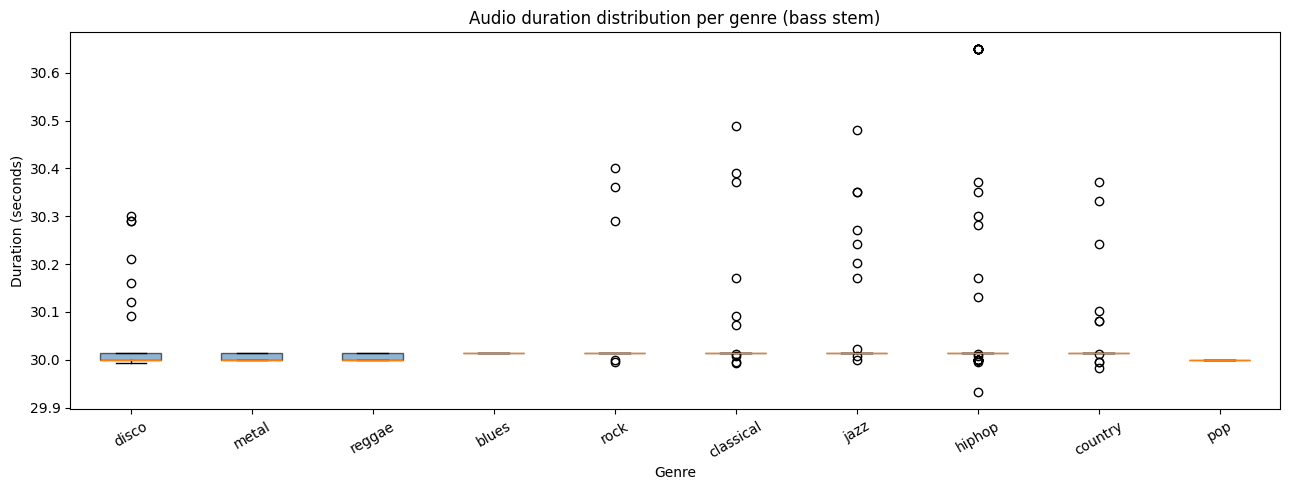

In [25]:
import soundfile as sf

durations = {}   # ← build it fresh, don't pre-initialise from genre_counts

for genre in os.listdir(GENRES_STEMS_DIRECTORY):
    genre_path = os.path.join(GENRES_STEMS_DIRECTORY, genre)
    if not os.path.isdir(genre_path):  
        continue
    durations[genre] = []               
    for song in os.listdir(genre_path):
        bass_path = os.path.join(genre_path, song, "bass.wav")
        if os.path.exists(bass_path):
            info = sf.info(bass_path)
            durations[genre].append(info.duration)

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(durations.values(), labels=durations.keys(), patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_title("Audio duration distribution per genre (bass stem)")
ax.set_ylabel("Duration (seconds)")
ax.set_xlabel("Genre")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### **Audio duration distribution**

we cut every clip to exactly 30 seconds. If some songs are only 20 seconds, the last 10 seconds are just silence (will be added zero padding). Too much padding in certain genres means those samples are artificially easy — the model might learn "short = this genre" instead of learning actual musical patterns.

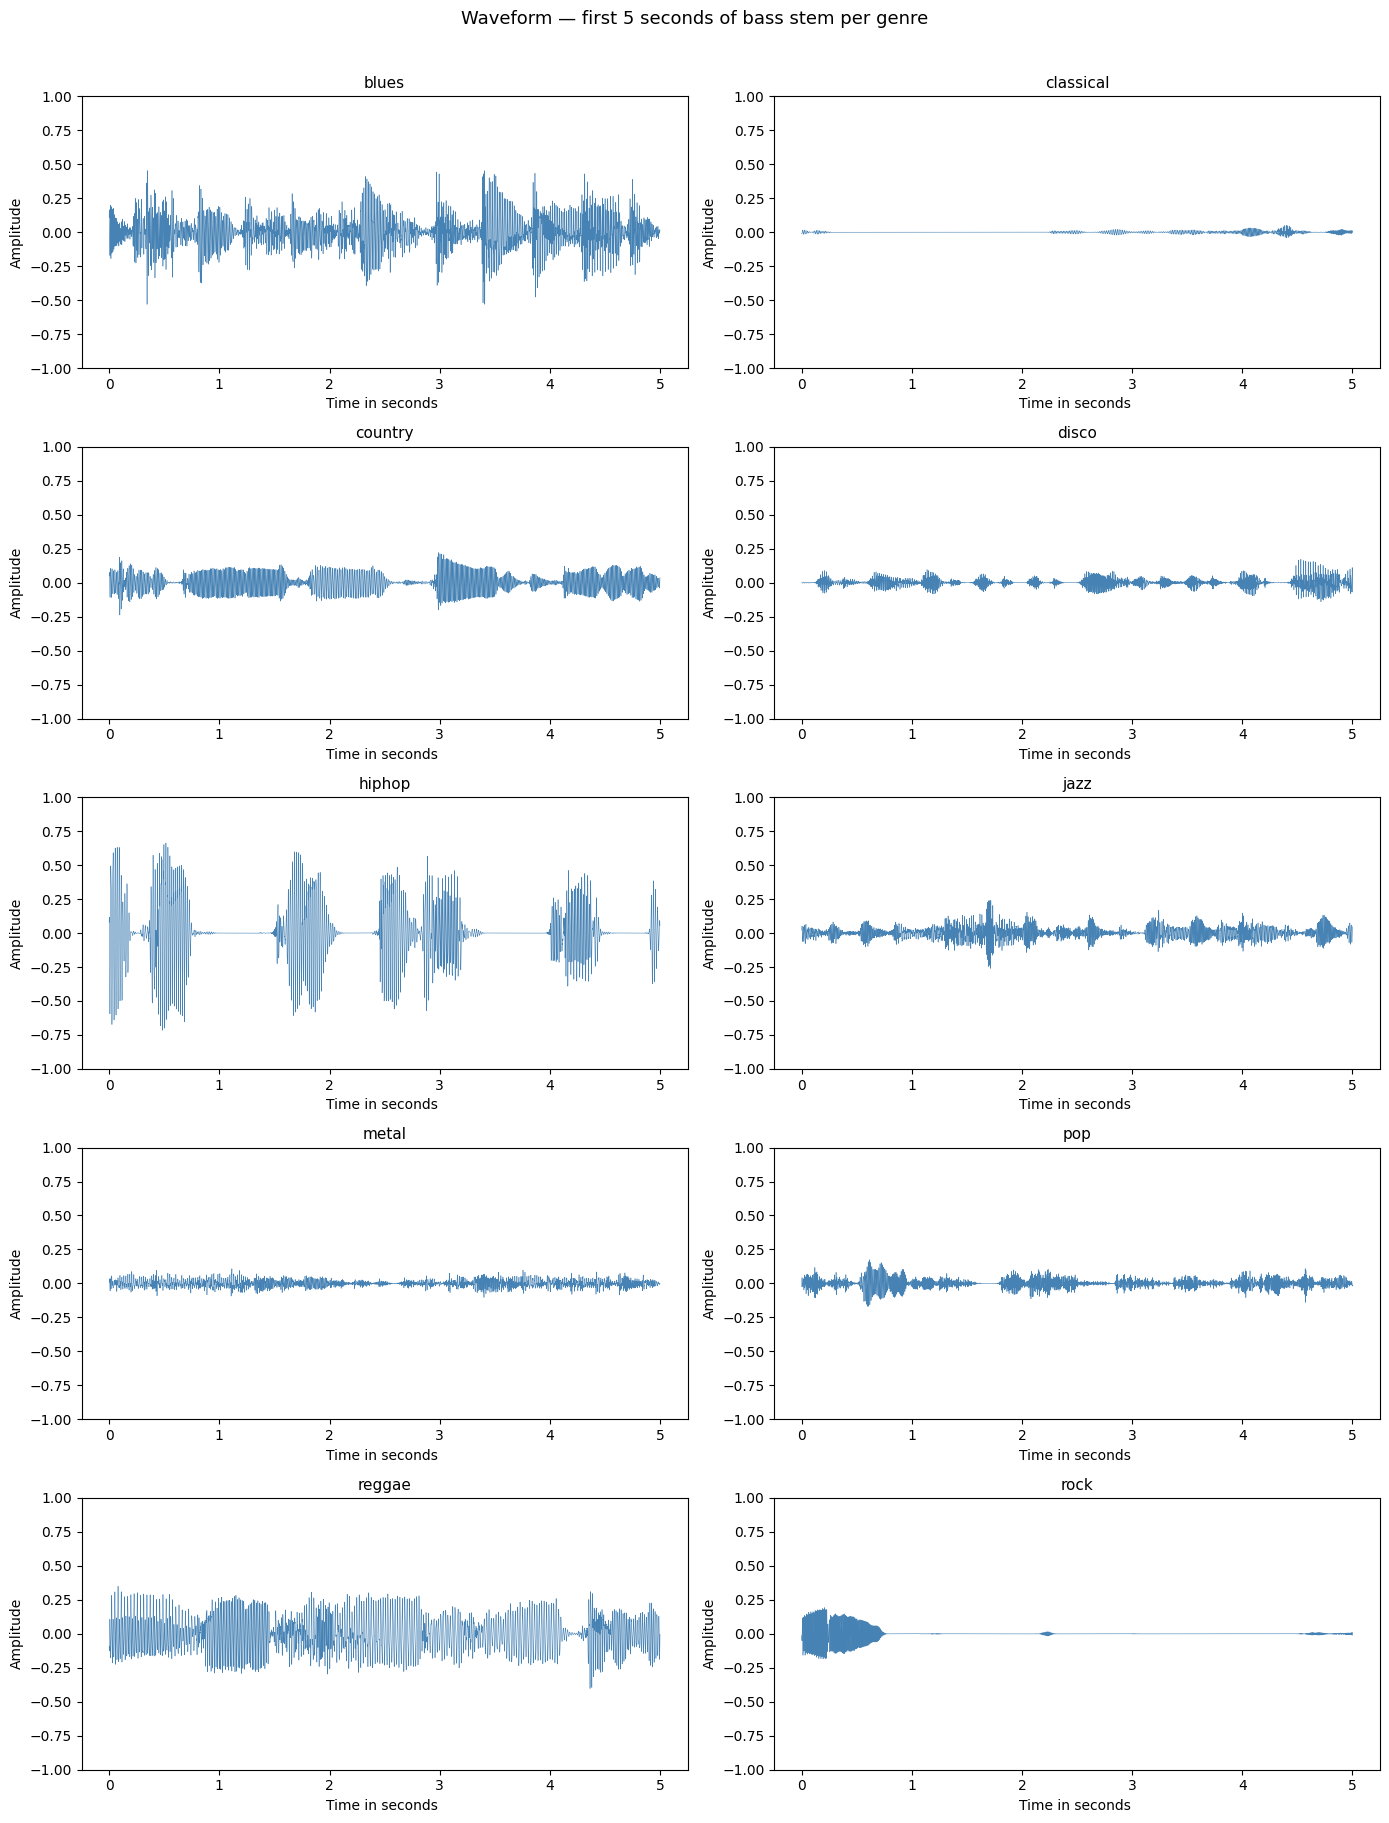

In [27]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, genre in enumerate(sorted(genre_label_map.keys())):
    genre_path = os.path.join(GENRES_STEMS_DIRECTORY, genre)
    song = os.listdir(genre_path)[0]
    
    bass = os.path.join(genre_path, song, "bass.wav")
    
    y, sr = torchaudio.load(bass)
    y = y.mean(0).numpy()
    t = np.linspace(0, len(y)/sr, len(y))
    
    axes[i].plot(t[:sr*5], y[:sr*5], linewidth=0.4, color="steelblue")  #take out only first 5s
    axes[i].set_title(genre, fontsize=11)
    
    axes[i].set_xlabel("Time in seconds ")
    axes[i].set_ylabel("Amplitude")
    axes[i].set_ylim(-1, 1)

plt.suptitle("Waveform — first 5 seconds of bass stem per genre", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### **Waveform comparison**


if we see the Metal and the classical, it look completely different as raw waves 
- metal is dense and loud throughout, 
- classical has quiet passages and sudden peaks.

  If two genres look similar as waveforms, your model will struggle to tell them apart. This is a quick visual sanity check that your genres are actually distinguishable.

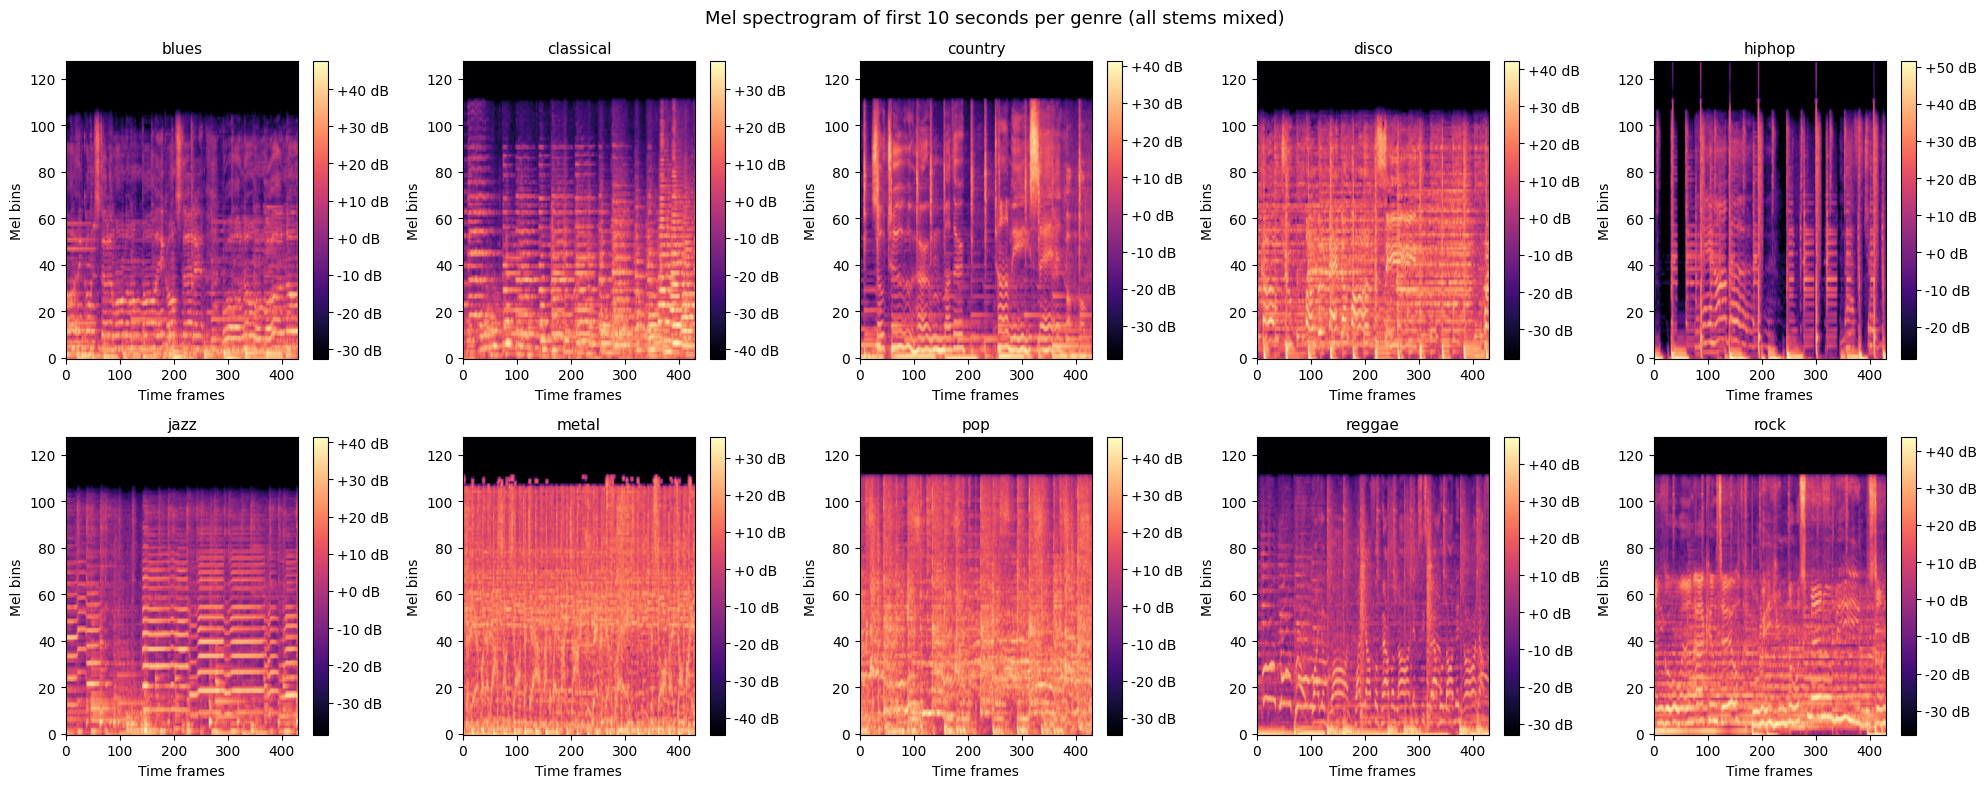

In [28]:
mel_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=2048,
                                  hop_length=512, n_mels=128, f_min=20, f_max=8000)
db_transform  = T.AmplitudeToDB(top_db=80)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, genre in enumerate(sorted(genre_label_map.keys())):
    genre_path = os.path.join(GENRES_STEMS_DIRECTORY, genre)
    song = os.listdir(genre_path)[0]
    
    # mix all stems
    mix = torch.zeros(1, SAMPLE_RATE * 10)
    for stem in ["bass.wav", "drums.wav", "vocals.wav", "other.wav"]:
        p = os.path.join(genre_path, song, stem)
        if os.path.exists(p):
            y, sr = torchaudio.load(p)
            y = y.mean(0, keepdim=True)
            if y.shape[1] >= SAMPLE_RATE * 10:
                mix += y[:, :SAMPLE_RATE * 10]
    
    mel  = mel_transform(mix)
    mel  = db_transform(mel).squeeze().numpy()
    
    im = axes[i].imshow(mel, aspect="auto", origin="lower", cmap="magma")
    axes[i].set_title(genre, fontsize=11)
    axes[i].set_xlabel("Time frames")
    axes[i].set_ylabel("Mel bins")
    plt.colorbar(im, ax=axes[i], format="%+2.0f dB")

plt.suptitle("Mel spectrogram of first 10 seconds per genre (all stems mixed)", fontsize=13)
plt.tight_layout()
plt.show()

#### **Mel spectrogram comparison**
- This is the most important EDA for your project because the spectrogram is literally what our model sees. The CNN, CRNN, and EfficientNet doesn't hear audio — they only see these images. If jazz and blues look nearly identical as spectrograms, no amount of model complexity will fix that. This plot tells you which genres are easy to separate visually and which ones will be your hardest classes.

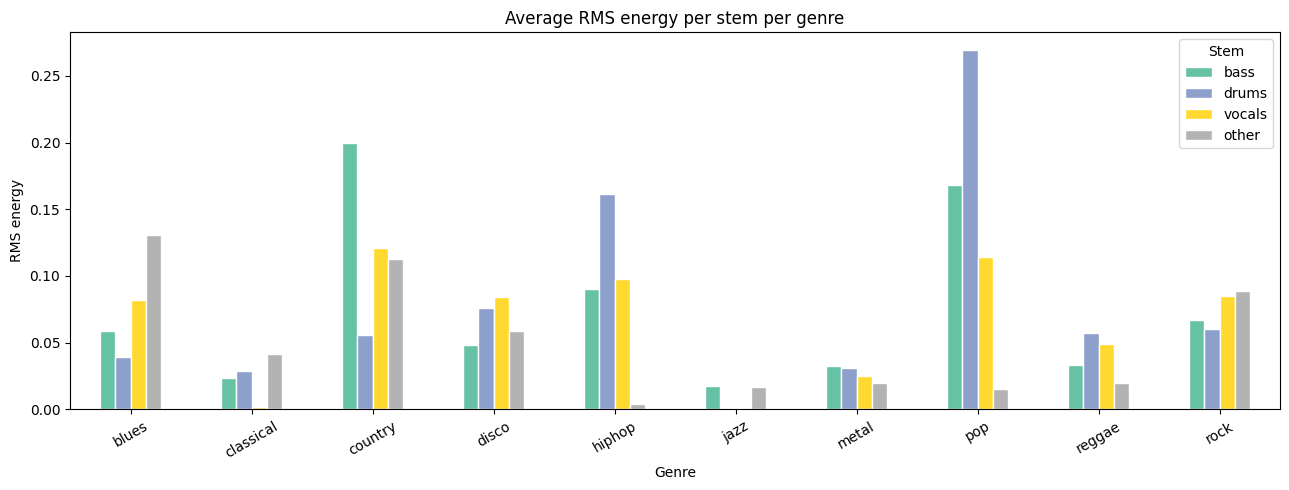

In [46]:
# Shows which stems are loudest in each genre
stem_names = ["bass.wav", "drums.wav", "vocals.wav", "other.wav"]
rms_data = {s.replace(".wav",""): [] for s in stem_names}
genre_labels = []

for genre in sorted(genre_counts.keys()):
    genre_path = os.path.join(GENRES_STEMS_DIRECTORY, genre)
    
    song = os.listdir(genre_path)[random.randint(0,99)]
    genre_labels.append(genre)
    for stem in stem_names:
        p = os.path.join(genre_path, song, stem)
        if os.path.exists(p):
            y, _ = torchaudio.load(p)
            rms = y.pow(2).mean().sqrt().item()
            rms_data[stem.replace(".wav","")].append(rms)
        else:
            rms_data[stem.replace(".wav","")].append(0)

df_rms = pd.DataFrame(rms_data, index=genre_labels)

df_rms.plot(kind="bar", figsize=(13, 5), colormap="Set2", edgecolor="white")
plt.title("Average RMS energy per stem per genre")
plt.ylabel("RMS energy")
plt.xlabel("Genre")
plt.xticks(rotation=30)
plt.legend(title="Stem")
plt.tight_layout()
plt.show()

#### **RMS energy per stem per genre**
- if we mix four stems together. If the drums stem in metal is 10× louder than in classical, the drum pattern alone gives away the genre — the model never needs to learn anything subtle. Conversely, if vocals are nearly silent in one genre, they contribute nothing useful to the mix. This tells you whether your stem mixing is balanced or whether one stem is dominating the signal.

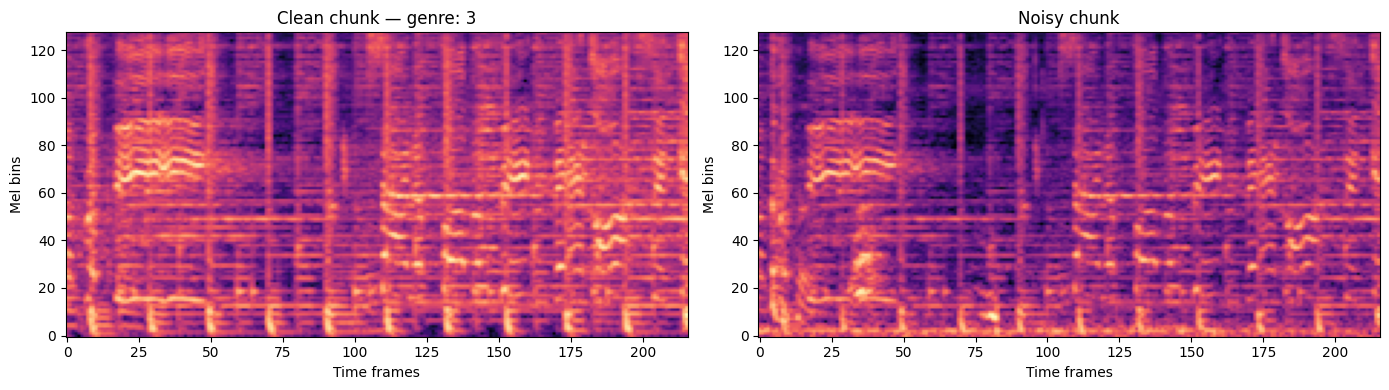

Clean audio:


Noisy audio:


In [47]:
from IPython.display import Audio

# pick one sample from your h5 file
with h5py.File("/kaggle/input/datasets/satyabratachowdhury/clean-chunk5s/clean_chunks5s.h5", "r") as hf:
    clean_audio = torch.tensor(hf["audio"][5], dtype=torch.float32)
    label = hf["genre"][0]

with h5py.File("/kaggle/input/datasets/satyabratachowdhury/new-noisy-chunk/noisy_chunksV2.h5", "r") as hf:
    noisy_audio = torch.tensor(hf["audio"][5], dtype=torch.float32)

def to_mel(audio):
    mel = mel_transform(audio)
    return db_transform(mel).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(to_mel(clean_audio), aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Clean chunk — genre: {label}")
axes[1].imshow(to_mel(noisy_audio), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Noisy chunk")
for ax in axes:
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
plt.tight_layout()
plt.show()

print("Clean audio:")
display(Audio(clean_audio.numpy(), rate=SAMPLE_RATE))
print("Noisy audio:")
display(Audio(noisy_audio.numpy(), rate=SAMPLE_RATE))

#### **Noise vs clean — spectrogram diff**
- test data is noisy mashups. Your training data starts clean and you add noise artificially.
- This comparison answers the critical question: does our augmented noisy data actually look like the test data? If the noise patterns look completely different, our model is training on the wrong kind of difficulty and will underperform at test time.

# === **Data preprocessing** =============

## ----- Helper function library

- `normalize()`
- `create_address_df()` 
- `load_audio()` 
- `create_clean_mashup()` 
- `mfcc_mean()`

In [6]:
DURATION = 30

# ============================== NORMALIZE ==============================

def normalize(waveform: torch.Tensor, eps: float = 1e-9) -> torch.Tensor:
    peak = waveform.abs().max()
    
    return waveform / (peak + eps)


# ============================== ADDRESS DF ==============================

def create_address_df(root: str) -> pd.DataFrame:
    """
    GENRES_STEMS_DIRECTORY -> address_df[bass, drums, other, vocals, genre]
    """
    rows = []

    for genre in os.listdir(root):
        genre_path = os.path.join(root, genre)
        a_path = os.path.join("genres_stems", genre)

        for song in os.listdir(genre_path):
            aa_path = os.path.join(a_path, song)

            rows.append({
                
                "bass": os.path.join(aa_path, "bass.wav"),
                "drums": os.path.join(aa_path, "drums.wav"),
                "other": os.path.join(aa_path, "other.wav"),
                "vocals": os.path.join(aa_path, "vocals.wav"),
                "genre": genre_label_map[genre],
            })

    return pd.DataFrame(rows)


# ============================== AUDIO LOADING ==============================

def load_audio( path: str, target_sr: int = SAMPLE_RATE, duration: int = DURATION ) -> torch.Tensor:
    """
    
    path(address) -> torchaudio.load -> mono -> ?resample -> 30s (cut/padding)

    >>> to load noise      load_audio(paht, target_sr=None, duration=None)
    """

    waveform, sample_rate = torchaudio.load(path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if target_sr is not None and sample_rate != target_sr:
        waveform = F.resample(waveform, sample_rate, target_sr)

    if duration is not None:
        target_len = target_sr * duration

        if waveform.shape[1] < target_len:
            pad_needed = target_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad_needed))
        else:
            waveform = waveform[:, :target_len]

    return waveform.to(DEVICE)


# ============================== MFCC ==============================

mfcc_transform = T.MFCC( sample_rate=SAMPLE_RATE, n_mfcc =40,melkwargs={
                                                                        "n_fft": 2048,
                                                                        "hop_length": 512,
                                                                        "n_mels": 128, }   )


def mfcc_mean(audio_tensor: torch.Tensor) -> np.ndarray:
    """
    raw audio -> MFCC -> mean (40-dim vector)
    """
    features = mfcc_transform(audio_tensor)
    return features.mean(dim=1).detach().cpu().numpy()


# ============================== CLEAN MASHUP ==============================

def create_clean_mashup(address_df: pd.DataFrame) -> pd.DataFrame:
    """
    address_df[bass, drums, other, vocals] -> dataframe[clean_mashup, genre]
    """
    data_list = []

    for _, row in address_df.iterrows():
        tracks = [
            load_audio(os.path.join(DATA_ROOT, row[stem]))
            for stem in STEM_KEYS
        ]

        mashup = torch.stack(tracks).sum(dim=0)

        data_list.append({
            "clean_mashup": mashup,
            "genre": row["genre"]
        })

    return pd.DataFrame(data_list)

- `build_noise_cashe()`
- `load_moise()`
- `chunk_audio()`
- `add_noise_to_chunk()`

In [8]:

# ============================== CONSTANTS ==============================

SAMPLE_RATE = 22050
CLIP_DURATION = 5  # in seconds
# CLIP_DURATION
HOP_DURATION = 2 # in seconds

CHUNK_SIZE = SAMPLE_RATE * CLIP_DURATION
HOP_SIZE = SAMPLE_RATE * HOP_DURATION

NOISE_LIST = ESC50["filename"].tolist()
ECS50_AUDIO = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"


# ============================== NOISE CACHE ==============================

def build_noise_cache(noise_files: list) -> dict:
    """
    Load all noise files into GPU memory once
    instead of loading from disk every time add_noise_to_chunk is called
    
    noise_files : list of file names
    returns : dict {filename: tensor(1, CHUNK_SIZE) on GPU}
    """
    cache = {}

    for path in noise_files:
        full_path = os.path.join(ECS50_AUDIO, path)

        
        waveform, sample_rate = torchaudio.load(full_path)

        if sample_rate != SAMPLE_RATE:
            waveform = AF.resample(waveform, sample_rate, SAMPLE_RATE)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)


        
        if waveform.shape[1] >= CHUNK_SIZE:
            start = random.randint(0, waveform.shape[1] - CHUNK_SIZE)
            waveform = waveform[:, start:start + CHUNK_SIZE]
        else:
            pad = CHUNK_SIZE - waveform.shape[1]
            start = random.randint(0, pad)
            waveform = torch.nn.functional.pad(waveform, (start, pad - start))

        cache[path] = waveform.to(DEVICE)

    return cache


# NOISE_CACHE = build_noise_cache(NOISE_LIST)



# ============================== LOAD NOISE ==============================

def load_noise(noise_path: str) -> torch.Tensor:
    """
    Instead of disk → CPU → GPU every call
    now just reads from GPU cache → random crop → return
    """
    noise = NOISE_CACHE[noise_path].clone()

    if noise.shape[1] >= CHUNK_SIZE:
        start = random.randint(0, noise.shape[1] - CHUNK_SIZE)
        noise = noise[:, start:start + CHUNK_SIZE]
    else:
        # pad = CHUNK_SIZE - noise.shape[1]
        # start = random.randint(0, pad)
        # noise = torch.nn.functional.pad(noise, (start, pad - start))
        start = random.randint(0, CHUNK_SIZE - noise.shape[1])
        noise_canvas = torch.zeros_like(CHUNK_SIZE)
        noise_canvas[:, start:start + noise_len] = noise
        noise = noise_canvas[:, start:start + noise_len]
        

    return noise


# ============================== CHUNK AUDIO ==============================

def chunk_audio(mashup: torch.Tensor) -> torch.Tensor:
    """
    30s mashup
        
            🢃
            
        [--5s--]
          [--5s--]
            [--5s--]
            
    mashup: (1, L) tensor on GPU
    returns: (N, 1, CHUNK_SIZE) tensor on GPU
    Pre-allocates output tensor instead of building list then stacking
    """
    
    length = mashup.shape[1]
    starts = range(0, length - CHUNK_SIZE, HOP_SIZE)
    n_chunks = len(starts)

    out = torch.empty(n_chunks, 1, CHUNK_SIZE, device=DEVICE)

    for idx, start in enumerate(starts):
        out[idx] = mashup[:, start:start + CHUNK_SIZE]

    return out



# ============================== AUGMENT ==============================

def augment_waveform(chunk: torch.Tensor, sr: int = SAMPLE_RATE) -> torch.Tensor:
    """
    chunk: (1, CHUNK_SIZE) tensor on GPU
    """

    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        chunk = F.gain(chunk, gain_db)

    if random.random() < 0.5:
        chunk = -chunk

    if random.random() < 0.3:
        steps = random.choice([-2, -1, 1, 2])
        chunk = F.pitch_shift(chunk.cpu(), sr, n_steps=steps).to(DEVICE)

    if random.random() < 0.3:
        rate = random.uniform(0.8, 1.2)
        chunk = F.speed(chunk, sr, factor=rate)[0]

        if chunk.shape[1] < CHUNK_SIZE:
            chunk = torch.nn.functional.pad(chunk, (0, CHUNK_SIZE - chunk.shape[1]))
        else:
            chunk = chunk[:, :CHUNK_SIZE]

    return chunk.to(DEVICE)




# ============================== ADD NOISE ==============================

def add_noise_to_chunk( chunks: torch.Tensor, noise_files: list, min_noises: int = 1,
                                   max_noises: int = 3, snr_db_range: tuple = (2, 13),) -> torch.Tensor:
    """
        [--5s--]
          [--5s--]
            [--5s--]
    
            🢃 < add one or multiple noise to each chunk>
            
        [--5s--]+noise
          [--5s--]+noise
            [--5s--]+noise

    
    chunks: (N, 1, CHUNK_SIZE) tensor on GPU
    Improvement: SNR tensor batch computed on GPU
    """

    result = chunks.clone()

    for i in range(len(result)):
        original = result[i].clone()

        n_noises = random.randint(min_noises, max_noises)
        chosen = random.sample(noise_files, n_noises)

        accumulated_noise = torch.zeros_like(original)

        for noise_path in chosen:
            noise = load_noise(noise_path)

            snr = torch.tensor( [random.uniform(*snr_db_range)], device=DEVICE )

            noisy = F.add_noise(original, noise, snr=snr)
            accumulated_noise += noisy - original

        if random.random() < 0.5:
            noisy_chunk = normalize(original + accumulated_noise)
        else:
            noisy_chunk = normalize(original)

        if random.random() < 0.5:
            result[i] = normalize(augment_waveform(noisy_chunk))
        else:
            result[i] = noisy_chunk

    return result




# ============================== PROCESS ==============================

def process_mashup( waveform: torch.Tensor, noise_files: list, augment: bool = True ) -> torch.Tensor:

    """
        [--5s--]+noise
          [--5s--]+noise
            [--5s--]+noise
        
            🢃 <saving to a data frame>
        
        [--5s--]+noise
        .............
        [--5s--]+noise

    
    waveform   : (1, L) tensor on GPU
    noise_files: list of noise file names
    augment    : True for training, False for val/inference
    """

    chunks = chunk_audio(waveform)

    if not augment:
        return chunks

    return add_noise_to_chunk(chunks, noise_files)


# ============================== DATASET ==============================

def generate_noisy_chunk_dataset( clean_mashup_df: pd.DataFrame, noise_list: list ) -> pd.DataFrame:
    """
    clean_mashup_df : DataFrame[audio, genre]
    noise_list : list of noise file names
    returns  : DataFrame[audio, genre]
    """

    records = []
    total = len(clean_mashup_df)

    for index, row in clean_mashup_df.iterrows():

        waveform = torch.tensor(
            row["audio"],
            dtype=torch.float32,
            device=DEVICE
        )

        noisy_chunks = process_mashup(waveform, noise_list, augment=True)

        for chunk in noisy_chunks:
            records.append({
                "audio": chunk.cpu(),
                "genre": row["genre"]
            })

        if (index + 1) % 100 == 0:
            print(f"Processed {index + 1}/{total}")

    print(f"Done — {len(records)} chunks generated")

    return pd.DataFrame(records)

In [9]:
# ============================== CROSS-SONG MIX ==============================



def mix_stems_cross_song_df(address_df, genre_label, n_mixes: int =1) :
    """
    address_df : DataFrame[bass, drums, other, vocals, genre]
    genre_label: int — genre to mix (e.g 3 for disco)
    n_mixes    : how many mixed waveforms to generate out of same genre

    returns    : list of (1, L) tensors
    """
    # --------------------- filter rows for this genre---------------------
    
    genre_df = address_df[address_df["genre"] == genre_label].reset_index(drop=True)

    if len(genre_df) < len(STEM_KEYS):
        print(f"Not enough songs for genre {genre_label} — need at least {len(STEM_KEYS)}")
        return []

    results = []

    for _ in range(n_mixes):

        #  picking out 4 different songs from the "genre_label" — no repeats
        chosen_rows = genre_df.sample(n=len(STEM_KEYS), replace=False)
        

        sigs = []
        for i, stem in enumerate(STEM_KEYS):
            path = os.path.join(DATA_ROOT, chosen_rows.iloc[i][stem])
            # [1---]
            # [-1--]
            # [--1-]
            # [---1]

            # --------------------- load stem
            
            y = load_audio(path, target_sr=SAMPLE_RATE, duration=None)

            # --------------------- random gain per stem
            
            gain = random.uniform(0.6, 1.4) # random roudnell of different stem
            sigs.append(y * gain)    # (1, L)
            
        print('.', end=' ')
        # -------------------- trim all stems to shortest length before stacking 
        min_len = min(s.shape[1] for s in sigs)
        sigs    = [s[:, :min_len] for s in sigs]
        
        # -------------------- normalize mashup
        
        mix = normalize( torch.stack(sigs, dim=0).sum(dim=0))  # (1, min_len)

       
        results.append(mix)   # (1, min_len) tensor
    

    return results   # list of (1, L) tensors



# ============================== DATASET GENERATION ==============================

def generate_cross_song_dataset(address_df, noise_list, n_mixes_per_genre=200):
    """
    address_df  : DataFrame[bass, drums, other, vocals, genre]
    noise_list  : list of noise file names
    n_mixes_per_genre : how many cross-song mashups per genre

    returns : DataFrame[audio, genre]
    """
    records = []
    genres  = address_df["genre"].unique()

    for genre_label in genres:
        genre_name = label_genre_map[genre_label]
        print(f"Generating {n_mixes_per_genre} mixes for {genre_name}...")

        mixes = mix_stems_cross_song_df( address_df, genre_label, n_mixes = n_mixes_per_genre )

        for mix in mixes:
            # -------------- chunk and add noise
            noisy_chunks = process_mashup(mix, noise_list, augment=True)
            

            for chunk in noisy_chunks:
                print("*",end="   ")
                records.append({
                    "audio": chunk.cpu(),
                    "genre": genre_label
                })

        print(f"  → {len(records)} total chunks so far")

    print(f"Done — {len(records)} total chunks")
    return pd.DataFrame(records)

In [9]:
# ============================== CHUNK AUDIO ==============================

def chunk_the_audio(mashup: torch.Tensor) -> torch.Tensor:
    """
    mashup: (1, L) tensor on GPU
    returns: (N, 1, CHUNK_SIZE) tensor on GPU
    """
    length = mashup.shape[1]
    starts = range(0, length - CHUNK_SIZE, HOP_SIZE)
    n_chunks = len(starts)

    out = torch.empty(n_chunks, 1, CHUNK_SIZE, device=DEVICE)

    for idx, start in enumerate(starts):
        out[idx] = mashup[:, start:start + CHUNK_SIZE]

    return out   # (N,1,CHUNK_SIZE) in GPU


# ============================== CLEAN DATASET ==============================

def generate_clean_chunk_dataset(
                                clean_mashup_df: pd.DataFrame
                            ) -> pd.DataFrame:
    """
    clean_mashup_df : DataFrame[audio, genre]
    returns         : DataFrame[audio, genre]
    """
    records = []
    total = len(clean_mashup_df)

    for index, row in clean_mashup_df.iterrows():
        #  numpy --> tensor directly on GPU (skip CPU intermediate)

        waveform = torch.tensor( row["audio"], dtype=torch.float32, device=DEVICE )   #  create directly on GPU

        clean_chunks = chunk_the_audio(waveform)

        for chunk in clean_chunks:
            records.append({
                "audio": chunk.cpu(),   # storing on CPU to save GPU memory
                "genre": row["genre"]
            })

    print(f"Done — {len(records)} chunks generated")

    return pd.DataFrame(records)

# clean_chunks=generate_clean_chunk_dataset(clean_mashup)
# clean_chunks

## ------ Dataset creation

In [10]:
# only for generation
address_df = create_address_df(GENRES_STEMS_DIRECTORY)

address_df

,bass,drums,other,vocals,genre
0,genres_stems/disco/disco.00052/bass.wav,genres_stems/disco/disco.00052/drums.wav,genres_stems/disco/disco.00052/other.wav,genres_stems/disco/disco.00052/vocals.wav,3
1,genres_stems/disco/disco.00098/bass.wav,genres_stems/disco/disco.00098/drums.wav,genres_stems/disco/disco.00098/other.wav,genres_stems/disco/disco.00098/vocals.wav,3
2,genres_stems/disco/disco.00028/bass.wav,genres_stems/disco/disco.00028/drums.wav,genres_stems/disco/disco.00028/other.wav,genres_stems/disco/disco.00028/vocals.wav,3
3,genres_stems/disco/disco.00069/bass.wav,genres_stems/disco/disco.00069/drums.wav,genres_stems/disco/disco.00069/other.wav,genres_stems/disco/disco.00069/vocals.wav,3
4,genres_stems/disco/disco.00015/bass.wav,genres_stems/disco/disco.00015/drums.wav,genres_stems/disco/disco.00015/other.wav,genres_stems/disco/disco.00015/vocals.wav,3
...,...,...,...,...,...
995,genres_stems/pop/pop.00090/bass.wav,genres_stems/pop/pop.00090/drums.wav,genres_stems/pop/pop.00090/other.wav,genres_stems/pop/pop.00090/vocals.wav,7
996,genres_stems/pop/pop.00092/bass.wav,genres_stems/pop/pop.00092/drums.wav,genres_stems/pop/pop.00092/other.wav,genres_stems/pop/pop.00092/vocals.wav,7
997,genres_stems/pop/pop.00031/bass.wav,genres_stems/pop/pop.00031/drums.wav,genres_stems/pop/pop.00031/other.wav,genres_stems/pop/pop.00031/vocals.wav,7
998,genres_stems/pop/pop.00080/bass.wav,genres_stems/pop/pop.00080/drums.wav,genres_stems/pop/pop.00080/other.wav,genres_stems/pop/pop.00080/vocals.wav,7


In [ ]:
# clean_mashup = create_clean_mashup(address_df)
# clean_mashup

In [9]:
# ================== clean chunks
# clean_chunks=generate_clean_chunk_dataset(clean_mashup)
# print("clean chunks generated")

Done — 13000 chunks generated
clean chunks generated


In [9]:

# ============== generate
# noisy_chunk=generate_noisy_chunk_dataset(clean_mashup,NOISE_LIST)

# print("noisy chunks generated")



Processed 100/1000 songs
Processed 200/1000 songs
Processed 300/1000 songs
Processed 400/1000 songs
Processed 500/1000 songs
Processed 600/1000 songs
Processed 700/1000 songs
Processed 800/1000 songs
Processed 900/1000 songs
Processed 1000/1000 songs
Done — 13000 chunks generated
noisy chunks generated


In [10]:
# noisy_chunk

,audio,genre
0,"[[tensor(-0.1193), tensor(-0.1484), tensor(-0....",3
1,"[[tensor(-0.1136), tensor(-0.0774), tensor(-0....",3
2,"[[tensor(0.1030), tensor(0.0416), tensor(-0.07...",3
3,"[[tensor(0.1735), tensor(0.2486), tensor(0.281...",3
4,"[[tensor(0.0562), tensor(0.0866), tensor(0.100...",3
...,...,...
12995,"[[tensor(-0.0020), tensor(0.2535), tensor(0.27...",7
12996,"[[tensor(-0.9726), tensor(-0.8776), tensor(-0....",7
12997,"[[tensor(-0.1952), tensor(-0.1660), tensor(-0....",7
12998,"[[tensor(-0.0565), tensor(-0.0496), tensor(-0....",7


In [2]:
#  generate cross-song dataset -- 100 mixes × 10 genres = 2000 mashups
# cross_song_df = generate_cross_song_dataset(address_df ,NOISE_LIST, n_mixes_per_genre = 100)   
                                     

# cross_song_df

## ------ Upload dataset to kaggle dataset

In [20]:
import h5py
import numpy as np

def save_mashup_dataset_hdf5(mashup_df, feature, label, duration=DURATION, output_path="cross_song.h5"):
    """
    mashup_df[audio (tensor), genre (int)] --> HDF5 file
    Fast version: batch convert to numpy first, then write in one shot
    """
    n            = len(mashup_df)
    sample_shape = mashup_df.iloc[0][feature].shape   # e.g. (1, 110250)

    print(f"Converting {n} samples to numpy...")

    # ── Step 1: batch convert all tensors to numpy at once
    # much faster than converting one by one inside iterrows()
    if isinstance(mashup_df.iloc[0][feature], torch.Tensor):
        audio_array = np.stack([
            row.cpu().numpy().astype(np.float32)
            for row in mashup_df[feature]
        ])                                             # (N, 1, CHUNK_SIZE)
    else:
        audio_array = np.stack([
            row.astype(np.float32)
            for row in mashup_df[feature]
        ])                                             # already numpy

    genre_array = np.array(mashup_df[label].tolist(), dtype=np.int32)  # (N,)

    print(f"Writing to HDF5...")

    # ── Step 2: write entire arrays at once — single disk write ✅
    with h5py.File(output_path, "w") as hf:
        hf.create_dataset(
            "audio",
            data        = audio_array,                 # ← entire array at once
            dtype       = np.float32,
            compression = "gzip",
            compression_opts = 4
        )
        hf.create_dataset(
            "genre",
            data  = genre_array,                       # ← entire array at once
            dtype = np.int32
        )
        hf.attrs["sample_rate"] = SAMPLE_RATE
        hf.attrs["duration"]    = duration
        hf.attrs["n_samples"]   = n
        hf.attrs["label_map"]   = str(label_genre_map)

    print(f"Saved {n} samples to '{output_path}'")
    print(f"File size: {os.path.getsize(output_path) / 1e6:.1f} MB")


def upload_mydata(noisy_chunk, upload_dir="/kaggle/working/my_upload"):
    os.makedirs(upload_dir, exist_ok=True)

    save_mashup_dataset_hdf5(
        noisy_chunk,
        feature     = "audio",
        label       = "genre",
        duration    = CLIP_DURATION,
        output_path = f"{upload_dir}/cross_song.h5"
    )
    print("saved noisy_chunk")
    import gc, kagglehub
    del noisy_chunk
    gc.collect()

    handle = "satyabratachowdhury/cross-song"   #  hyphen not underscore ✅
    kagglehub.dataset_upload(handle, upload_dir)
    print(f"Uploaded to kaggle: {handle}")


In [23]:
# for uploading to data
upload_mydata(cross_song_df, upload_dir="/kaggle/working/my_upload")

Converting 13000 samples to numpy...
Writing to HDF5...
Saved 13000 samples to '/kaggle/working/my_upload/cross_song.h5'
File size: 5308.1 MB
saved noisy_chunk
Uploading Dataset https://api.kaggle.com/datasets/satyabratachowdhury/cross-song ...
Starting upload for file /kaggle/working/my_upload/cross_song.h5


Uploading: 100%|██████████| 5.31G/5.31G [01:59<00:00, 44.4MB/s] 

Upload successful: /kaggle/working/my_upload/cross_song.h5 (5GB)


Your dataset has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/satyabratachowdhury/cross-song
Uploaded to kaggle: satyabratachowdhury/cross-song


In [22]:
# import os

# # ── delete specific file
# os.remove("/kaggle/working/my_upload/cross_song.h5")
# print("deleted clean_chunks.h5")

# # ── verify it's gone
# print(os.listdir("/kaggle/working/my_upload"))

deleted clean_chunks.h5
[]


In [14]:
# clean mashup full length

# CLAEN_MASHUP="/kaggle/input/datasets/satyabratachowdhury/h5test/mashup_dataset.h5"

# with h5py.File(CLAEN_MASHUP, "r") as hf:
#     clean_mashup = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})

# clean_mashup

,audio,genre
0,"[[-0.099000365, -0.1232371, -0.108761705, -0.1...",3
1,"[[-0.07039219, -0.095290944, -0.12003371, -0.0...",3
2,"[[0.062521175, 0.06890483, 0.09337951, 0.03029...",3
3,"[[-0.13072398, -0.14504933, -0.1305793, -0.062...",3
4,"[[-0.11730692, -0.08672285, -0.03114814, -0.10...",3
...,...,...
8995,"[[0.31263584, 0.23262405, 0.13484783, -0.00427...",7
8996,"[[0.06463061, 0.097492725, 0.09283483, 0.09529...",7
8997,"[[-0.5172717, -0.5076689, -0.48604706, -0.4579...",7
8998,"[[0.026363058, -0.03666307, -0.085812375, -0.0...",7


In [17]:
cmindx=random.randint(0,999)
Audio(clean_mashup.iloc[cmindx,0], rate=SAMPLE_RATE)

## ------ loading dataset

In [ ]:
# address dataframe
with h5py.File("/kaggle/input/datasets/satyabratachowdhury/h5test/address_df.csv", "r") as hf:
    address_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # clean mashups 30s
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/h5test/mashup_dataset.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # clean chunks/clips 5s
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/clean-chunk5s/clean_chunks5s.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # noisy chunks v1
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/new-noisy-chunk/noisy_chunksV2.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # noisy chunks v2
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/new-noisy-chunk/noisy_chunksV2.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # cross songs
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/cross-song/cross_song.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})
    
# # mixed chunks 5s (clean-30%, noisy v1-30%, noisy v2 - 30% ) 
# with h5py.File("/kaggle/input/datasets/satyabratachowdhury/mixed-chunks5s303030/mixed_chunks5s303030.h5", "r") as hf:
#     sound_df = pd.DataFrame({key: list(hf[key][:]) for key in hf.keys()})

sound_df

In [ ]:
# ── check all variables and their sizes
import sys

def show_memory():
    variables = []
    for name, obj in globals().items():
        if name.startswith("_"):
            continue

        # ── DataFrames — deep=True measures actual cell contents
        if isinstance(obj, pd.DataFrame):
            size = obj.memory_usage(deep=True).sum()

        # ── numpy arrays
        elif isinstance(obj, np.ndarray):
            size = obj.nbytes

        # ── torch tensors
        elif isinstance(obj, torch.Tensor):
            size = obj.element_size() * obj.nelement()

        # ── dicts and lists — use sys.getsizeof
        else:
            size = sys.getsizeof(obj)

        variables.append((name, type(obj).__name__, size))

    # sort by size
    variables.sort(key=lambda x: x[2], reverse=True)

    print(f"{'Variable':<30} {'Type':<20} {'Size':>10}")
    print("-" * 62)
    for name, dtype, size in variables[:20]:
        print(f"{name:<30} {dtype:<20} {size/1e6:>8.2f} MB")

show_memory()

In [9]:
import gc


# del mixed_chunks
# ── force garbage collector to free RAM immediately
gc.collect()

# ── if using GPU, free GPU memory too
torch.cuda.empty_cache()

# ===== data loader =============

In [12]:
from sklearn.model_selection import train_test_split
import gc


# ============================== ARRAY CONVERSION ==============================

X = np.array(sound_df["audio"].tolist())
y = np.array(sound_df["genre"].tolist())


# ============================== MEMORY CLEANUP ==============================

del sound_df
gc.collect()
torch.cuda.empty_cache()


# ============================== TRAIN-VAL SPLIT ==============================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    # stratify=y
)


# ============================== SHAPE LOGGING ==============================

print(f"X shape      : {X.shape}")
print(f"Train shape  : {X_train.shape}")
print(f"Val shape    : {X_val.shape}")


# ============================== FINAL CLEANUP ==============================

del X, y
gc.collect()
torch.cuda.empty_cache()

X shape      : (13000, 1, 110250)
Train shape  : (10400, 1, 110250)
Val shape    : (2600, 1, 110250)


In [13]:
from functools import partial
import random
import torch
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader


# ============================== CONSTANTS ==============================

SAMPLE_RATE = 22050
CHUNK_SIZE  = SAMPLE_RATE * 5
HOP_SIZE    = SAMPLE_RATE * 2

N_MELS     = 224
N_FFT      = 2048
HOP_LENGTH = 493


# ============================== TRANSFORMS ==============================

mel_transform = T.MelSpectrogram(
                            sample_rate=SAMPLE_RATE,
                            n_fft=N_FFT,
                            hop_length=HOP_LENGTH,
                            n_mels=N_MELS,
                            f_min=20,
                            f_max=8000,
                        ).to(DEVICE)

db_transform = T.AmplitudeToDB(top_db=80)


# ============================== MEL SPEC ==============================

def chunk_to_melspec(chunk: torch.Tensor, training: bool = False) -> torch.Tensor:
    """
    chunk    : (1, CHUNK_SIZE) tensor
    training : applies SpecAugment if True
    returns  : (1, N_MELS, T)
    """
    if chunk.dim() == 1:
        chunk = chunk.unsqueeze(0)

    chunk = chunk.to(DEVICE)

    mel = mel_transform(chunk)
    mel = db_transform(mel)

    mean = mel.mean()
    std = mel.std() + 1e-9
    mel = (mel - mean) / std

    if training:
        if random.random() < 0.5:
            mel = T.TimeMasking(time_mask_param=40)(mel)
        if random.random() < 0.5:
            mel = T.FrequencyMasking(freq_mask_param=30)(mel)
        if random.random() < 0.3:
            mel = T.TimeMasking(time_mask_param=20)(mel)
            mel = T.FrequencyMasking(freq_mask_param=15)(mel)

    return mel.cpu()


# ============================== DATASET ==============================

class AudioDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        audio = self.X[idx]
        genre = self.y[idx]

        if self.transform is not None:
            audio = self.transform(audio)

        return audio, genre


# ============================== TRANSFORMS SETUP ==============================

train_transform = partial(chunk_to_melspec, training=True)
val_transform   = partial(chunk_to_melspec, training=False)


# ============================== DATASETS ==============================

train_ds = AudioDataset(X_train, y_train, transform=train_transform)
val_ds   = AudioDataset(X_val, y_val, transform=val_transform)


# ============================== DATALOADERS ==============================

trainloader = DataLoader( train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=True )

valloader = DataLoader( val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True )

### checking input

In [61]:


b= mel_transform(a)
db_transform = T.AmplitudeToDB(top_db=80).to(DEVICE)

c=db_transform(b)
print(c)

import matplotlib.pyplot as plt

# mel is (3, 224, 224) — all 3 channels are identical, just plot channel 0
plt.figure(figsize=(10, 4))
plt.imshow(c.cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
plt.colorbar(label="dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.show()

NameError: name 'a' is not defined

# ========= ML model (Base) ============

In [11]:
# ============================== RESET W&B ==============================
import wandb
wandb.finish()   
wandb.login()

# ============================== IMPORTS ==============================
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# ============================== CONFIG ==============================
DEVICE = "cpu"   
SAMPLE_RATE = 16000
DURATION = 10
TARGET_LEN = SAMPLE_RATE * DURATION
SR=SAMPLE_RATE
STEM_KEYS = ["drums", "bass", "vocals", "other"]

# ============================== AUDIO ==============================
def load_audio_fast(path):
    y, sr = torchaudio.load(path)

    # mono
    if y.shape[0] > 1:
        y = y.mean(dim=0, keepdim=True)

    # resample
    if sr != SAMPLE_RATE:
        y = AF.resample(y, sr, SAMPLE_RATE)

    # pad/trim
    if y.shape[1] < TARGET_LEN:
        y = torch.nn.functional.pad(y, (0, TARGET_LEN - y.shape[1]))
    else:
        y = y[:, :TARGET_LEN]

    return y  # keep on CPU


# ============================== MFCC ==============================
mfcc_transform = T.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=40,
    melkwargs={
        "n_fft": 2048,
        "hop_length": 512,
        "n_mels": 128,
    }
)

def mfcc_mean_fast(audio_tensor):
    # (1, T) -> (40, time)
    mfcc = mfcc_transform(audio_tensor)

    # mean over time → (40,)
    return mfcc.mean(dim=1).squeeze().numpy()


# ============================== FEATURE EXTRACTION ==============================
def create_feature_fast(df, is_test=False):
    print("creating mfcc data set ")
    records = []

    for row in tqdm(df.itertuples(index=False), total=len(df)):  
        # print(row)
        # ---- load & mix stems ----
        mashup = None
        if is_test:
            col = "filename"
            path = os.path.join(DATA_ROOT, getattr(row, col))
            # print(path)
            mashup = load_audio_fast(path)

        else:
            
            for stem in STEM_KEYS:
                path = os.path.join(DATA_ROOT, getattr(row, stem))
                # print(path)
                audio = load_audio_fast(path)
    
                mashup = audio if mashup is None else mashup + audio

        # ---- to MFCC ----
        features = mfcc_mean_fast(mashup)

        entry = {f"mfcc_{i}": v for i, v in enumerate(features)}
        if not is_test:
            entry["genre"] = row.genre

        records.append(entry)

    return pd.DataFrame(records)


# ============================== BUILD FEATURES ==============================

train_mfcc_df = create_feature_fast(address_df)

# ============================== SPLIT ==============================
X = train_mfcc_df.drop("genre", axis=1).values
y = train_mfcc_df["genre"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================== TRAIN FUNCTION ==============================
def train_model(config=None):
    with wandb.init(config=config):

        config = wandb.config

        model = XGBClassifier(
            n_estimators=config.n_estimators,
            max_depth=config.max_depth,
            learning_rate=config.learning_rate,
            subsample=config.subsample,
            colsample_bytree=config.colsample_bytree,
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss"
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        acc = accuracy_score(y_val, preds)
        f1  = f1_score(y_val, preds, average="macro")

        print(f"Run config: {dict(config)}")
        print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")
        print("-" * 50)

        wandb.log({
            "accuracy": acc,
            "f1_macro": f1
        })

# ============================== SWEEP CONFIG ==============================
sweep_config = {
    "method": "random",
    "metric": {
        "name": "f1_macro",
        "goal": "maximize"
    },
    "parameters": {
        "n_estimators": {"values": [200, 300, 500]},
        "max_depth": {"values": [4, 6, 8]},
        "learning_rate": {"values": [0.01, 0.05, 0.1]},
        "subsample": {"values": [0.8, 1.0]},
        "colsample_bytree": {"values": [0.8, 1.0]},
    }
}

# ============================== CREATE SWEEP ==============================
sweep_id = wandb.sweep(
    sweep_config,
    project="22F3003016-t12026",
    entity="22F3003016-dl-genai-project"
)

# ============================== RUN SWEEP ==============================
wandb.agent(sweep_id, function=train_model, count=10)



Create sweep with ID: xw48vw63
Sweep URL: https://wandb.ai/22F3003016-dl-genai-project/22F3003016-t12026/sweeps/xw48vw63


wandb: Agent Starting Run: k45e45kf with config:
wandb: 	colsample_bytree: 0.8
wandb: 	learning_rate: 0.01
wandb: 	max_depth: 6
wandb: 	n_estimators: 500
wandb: 	subsample: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run config: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500, 'subsample': 1}
Accuracy: 0.3100, F1: 0.2931
--------------------------------------------------


accuracy,▁
f1_macro,▁
accuracy,0.31
f1_macro,0.29312


wandb: Agent Starting Run: myxiz2wu with config:
wandb: 	colsample_bytree: 0.8
wandb: 	learning_rate: 0.01
wandb: 	max_depth: 4
wandb: 	n_estimators: 200
wandb: 	subsample: 0.8
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

Run config: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1}
Accuracy: 0.3000, F1: 0.2855
--------------------------------------------------


accuracy,▁
f1_macro,▁
accuracy,0.3
f1_macro,0.28546


wandb: Agent Starting Run: 9bfb4k40 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	learning_rate: 0.01
wandb: 	max_depth: 6
wandb: 	n_estimators: 200
wandb: 	subsample: 0.8
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Run config: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.2800, F1: 0.2577
--------------------------------------------------


accuracy,▁
f1_macro,▁
accuracy,0.28
f1_macro,0.25769


In [13]:
# best out come from the training
# Run config: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
# ============================== BEST MODEL ==============================
best_config = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

best_model = XGBClassifier(
    **best_config,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

best_model.fit(X_train, y_train)

# ============================== EVALUATION ==============================
preds = best_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, preds))
print(classification_report(y_val, preds))

# ============================== TEST ==============================
# X_test = test_mfcc_df.values
test_mfcc_df = create_feature_fast(test,is_test=True)
test_preds = best_model.predict(test_mfcc_df)

sample_submission["genre"] = [GENRES[p] for p in test_preds]

sample_submission.to_csv("/kaggle/working/submission.csv", index=False)

print(" Submission saved!")

Validation Accuracy: 0.28
              precision    recall  f1-score   support

           0       0.18      0.10      0.13        20
           1       0.50      0.85      0.63        20
           2       0.27      0.20      0.23        20
           3       0.19      0.20      0.20        20
           4       0.10      0.10      0.10        20
           5       0.53      0.50      0.51        20
           6       0.21      0.40      0.27        20
           7       0.22      0.20      0.21        20
           8       0.27      0.20      0.23        20
           9       0.12      0.05      0.07        20

    accuracy                           0.28       200
   macro avg       0.26      0.28      0.26       200
weighted avg       0.26      0.28      0.26       200

✅ Submission saved!


In [ ]:
# prior version , working

# 1. Setup the transformer
# mfcc_transform = torchaudio.transforms.MFCC(sample_rate=SAMPLE_RATE, n_mfcc=40)
# ===========================================
# library functions
# load_audio()
# mfcc_transform = T.MFCC()
# mfcc_mean()
# ===========================================
def load_audio(path, target_sr=SAMPLE_RATE, duration=DURATION):
    y,sr=torchaudio.load(path) # shape [2,22050] not mono
    if y.shape[0]>1:
        y=y.mean(dim=0, keepdim=True) # not shape is [1,22050]
        
    if (target_sr != None) and sr != target_sr:
        y=AF.resample(y,sr,target_sr)
    
    if duration != None:
        target_len = target_sr * duration 
        if y.shape[1] < target_len:
            pad_needed = target_len - y.shape[1]
            y = torch.nn.functional.pad(y,(0,pad_needed)) # adding 0 padding to make equal length
        else:
            y = y[:,:target_len]

    return y.to(DEVICE) # tensor of shape [1,target_len]

mfcc_transform = T.MFCC( sample_rate=SAMPLE_RATE, n_mfcc =40,melkwargs={
                                                                        "n_fft": 2048,
                                                                        "hop_length": 512,
                                                                        "n_mels": 128, }   )


def mfcc_mean(audio_tensor: torch.Tensor) -> np.ndarray:
    """
    raw audio -> MFCC -> mean (40-dim vector)
    """
    features = mfcc_transform(audio_tensor)
    return features.mean(dim=1).detach().cpu().numpy()



    features = mfcc_transform(audio_tensor)
    
    # Collapse the time dimension (Take the mean across time)
    # This leaves us with a vector of 40 numbers per file
    mean_features = features.mean(dim=1).detach().numpy()
        
    return mean_features




def load_mashup_mfcc(wav_dir, row, istest=False):
    mixed=load_create_mashup(wav_dir, row,istest=False) # b+d+o+v

    mean_mfcc= mfcc_mean(mixed)

    
    return mean_mfcc

def create_feature(address_df):
    data_list = []


    # Loop through your dataset
    
    for index, row in address_df.iterrows():
        
        mashup = sum([ load_audio(os.path.join(DATA_ROOT, row[stem]))
                                for stem in STEM_KEYS ])

        features_vector =  mfcc_mean(mashup)
        
        # Create a dictionary for this specific file
        entry = {f'mfcc_{i}': val for i, val in enumerate(features_vector[0])}
        
        entry['genre'] = row['genre']
        
        data_list.append(entry)
    
    # create feature dataframe
    mfcc_df = pd.DataFrame(data_list)
    return mfcc_df


mfcc_df=create_feature(address_df)
print(mfcc_df.head())






from xgboost import XGBClassifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = mfcc_df.drop('genre', axis=1)
y = mfcc_df['genre']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,stratify = y)




clf_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

clf = GradientBoostingClassifier(n_estimators=200, max_depth=5)






clf_xgb.fit(X_train, y_train)



preds = clf_xgb.predict(X_val)
acc = accuracy_score(y_val, preds)

print("Validation Accuracy:", acc)

print(classification_report(y_val, preds))


# ========= DL models ================

## --- simple CNN 
(Convolutional Neural Network)/NN (Neural Network) 

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, n_classes: int = 10):
        super().__init__()

        # ============================== FEATURE EXTRACTOR ==============================
        # Downsamples spatial resolution while increasing channel depth
        # Final output: (batch, 256, 1, 1)

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout2d(p=0.2),
        )

        # ============================== CLASSIFIER ==============================

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)
        x = x.flatten(1)
        x = self.classifier(x)
        return x

# ======================== model shapes chacker ==========================
def print_model_shapes(model, input_size=(1, 1, 224, 224)):
    x = torch.randn(input_size)
    for layer in model.cnn:
        x = layer(x)
        print(f"{layer.__class__.__name__}: {x.shape}")

model_SimpleCNN = SimpleCNN()
print_model_shapes(model_SimpleCNN, input_size=(1, 1, 224, 224))

Conv2d: torch.Size([1, 32, 224, 224])
BatchNorm2d: torch.Size([1, 32, 224, 224])
ReLU: torch.Size([1, 32, 224, 224])
MaxPool2d: torch.Size([1, 32, 112, 112])
Dropout2d: torch.Size([1, 32, 112, 112])
Conv2d: torch.Size([1, 64, 112, 112])
BatchNorm2d: torch.Size([1, 64, 112, 112])
ReLU: torch.Size([1, 64, 112, 112])
MaxPool2d: torch.Size([1, 64, 56, 56])
Dropout2d: torch.Size([1, 64, 56, 56])
Conv2d: torch.Size([1, 128, 56, 56])
BatchNorm2d: torch.Size([1, 128, 56, 56])
ReLU: torch.Size([1, 128, 56, 56])
MaxPool2d: torch.Size([1, 128, 28, 28])
Dropout2d: torch.Size([1, 128, 28, 28])
Conv2d: torch.Size([1, 256, 28, 28])
BatchNorm2d: torch.Size([1, 256, 28, 28])
ReLU: torch.Size([1, 256, 28, 28])
AdaptiveAvgPool2d: torch.Size([1, 256, 1, 1])
Dropout2d: torch.Size([1, 256, 1, 1])


## --- CRNN (CNN + RNN/LSTM/GRU)

In [15]:
import torch
import torch.nn as nn


class CRNN(nn.Module):
    def __init__(
        self,
        n_classes: int = 10,
        hidden_size: int = 256,
        num_layers: int = 2,
        rnn_type: str = "GRU"
    ):
        super().__init__()

        # ============================== CNN FEATURE EXTRACTOR ==============================
        # Extracts spatial features from spectrogram
        # Collapses frequency dimension while preserving time dimension

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Collapse frequency dimension → keep time dimension dynamic
            nn.AdaptiveAvgPool2d((1, None)),

            nn.Dropout2d(p=0.2),
        )

        # ============================== RNN (TEMPORAL MODELING) ==============================

        rnn_class = nn.GRU if rnn_type == "GRU" else nn.LSTM

        self.rnn = rnn_class(
            input_size=256,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0.0,
        )

        # ============================== CLASSIFIER ==============================

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ============================== CNN ==============================
        x = self.cnn(x)

        # ============================== RESHAPE ==============================
        # (batch, channels, freq=1, time) → (batch, time, features)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        # ============================== RNN ==============================
        x, _ = self.rnn(x)

        # ============================== TEMPORAL POOLING ==============================
        x = torch.mean(x, dim=1)

        # ============================== CLASSIFIER ==============================
        x = self.classifier(x)

        return x

# ==================== shape reference (debug helper) ===========

def debug_shapes(model):
    x = torch.randn(1, 1, 224, 224)
    x = model.cnn(x)
    print("After CNN:", x.shape)

    x = x.squeeze(2).permute(0, 2, 1)
    print("Before RNN:", x.shape)


model_crnn = CRNN()
debug_shapes(model_crnn)

After CNN: torch.Size([1, 256, 1, 28])
Before RNN: torch.Size([1, 28, 256])


## --- EfficientNet_B0_Weights.IMAGENET1K_V1

In [16]:
import torch
import torch.nn as nn
import torchvision.models as models


class EfficientNetB0(nn.Module):
    def __init__(
        self,
        n_classes: int = len(label_genre_map),
        freeze_backbone: bool = True
    ):
        super().__init__()

        # ============================== BACKBONE ==============================
        # Pretrained EfficientNet-B0 (ImageNet)

        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b0(weights=weights)

        # ============================== INPUT ADAPTATION ==============================
        # Convert RGB (3 channels) → Mono spectrogram (1 channel)

        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=2,
            padding=1,
            bias=False
        )

        # ============================== FREEZE BACKBONE ==============================

        if freeze_backbone:
            for name, param in self.backbone.features.named_parameters():
                param.requires_grad = name.startswith("0.0")

        # ============================== CLASSIFIER ==============================

        self.backbone.classifier = nn.Sequential(
            nn.BatchNorm1d(1280),
            nn.Dropout(p=0.5),
            nn.Linear(1280, 512),
            nn.ReLU(),

            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

## --- EfficientNetTransformer

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models


class EfficientNetTransformer(nn.Module):
    def __init__(
        self,
        n_classes: int = 10,
        transformer_dim: int = 256,
        n_heads: int = 8,
        n_layers: int = 2,
        dropout: float = 0.2
    ):
        super().__init__()

        # ============================== CNN BACKBONE ==============================
        # EfficientNet-B0 pretrained on ImageNet
        # Adapted for mono spectrogram input

        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b0(weights=weights)

        backbone.features[0][0] = nn.Conv2d(
                                        in_channels=1,
                                        out_channels=32,
                                        kernel_size=3,
                                        stride=2,
                                        padding=1,
                                        bias=False
                                    )

        self.cnn = backbone.features
        cnn_out_channels = 1280  # EfficientNet-B0 final feature channels

        # ============================== FEATURE PROJECTION ==============================
        # Map CNN features → Transformer dimension

        self.feature_projection = nn.Linear(
                                            cnn_out_channels,
                                            transformer_dim
                                        )

        # ============================== TRANSFORMER ==============================

        encoder_layer = nn.TransformerEncoderLayer(
                                            d_model=transformer_dim,
                                            nhead=n_heads,
                                            dim_feedforward=transformer_dim * 4,
                                            dropout=dropout,
                                            batch_first=True
                                        )

        self.transformer = nn.TransformerEncoder(
                                                encoder_layer,
                                                num_layers=n_layers
                                            )

        # ============================== ATTENTION POOLING ==============================
        # Learns importance of each token

        self.attention = nn.Sequential(
                                    nn.Linear(transformer_dim, 128),
                                    nn.Tanh(),
                                    nn.Linear(128, 1)
                                )

        # ============================== CLASSIFIER ==============================

        self.classifier = nn.Sequential(
                                nn.BatchNorm1d(transformer_dim),
                                nn.Dropout(0.4),
                    
                                nn.Linear(transformer_dim, 256),
                                nn.ReLU(),
                    
                                nn.Dropout(0.3),
                                nn.Linear(256, n_classes)
                            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # ============================== CNN ==============================
        x = self.cnn(x)

        B, C, H, W = x.shape

        # ============================== SEQUENCE CONVERSION ==============================
        # (B, C, H, W) → (B, tokens=H*W, C)

        x = x.permute(0, 2, 3, 1)
        x = x.reshape(B, H * W, C)

        # ============================== FEATURE PROJECTION ==============================
        x = self.feature_projection(x)

        # ============================== TRANSFORMER ==============================
        x = self.transformer(x)

        # ============================== ATTENTION POOLING ==============================
        attn = self.attention(x)
        attn = torch.softmax(attn, dim=1)

        x = (x * attn).sum(dim=1)

        # ============================== CLASSIFIER ==============================
        x = self.classifier(x)

        return x

## --- AST (Audio Spectrogram Transformer)

In [18]:

model_ast = ASTForAudioClassification.from_pretrained(
                                                "MIT/ast-finetuned-audioset-10-10-0.4593",
                                                num_labels=10,
                                                ignore_mismatched_sizes=True
                                            )



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


# ========== Training Loop definition (for DL) =========

In [28]:
from sklearn.metrics import f1_score
import copy
import torch
import matplotlib.pyplot as plt

FOLDS = 1
EPOCHS = 20
BATCH_SIZE = 32 
LR_wb = 3e-5
# WEIGHT_DECAY = 1e-2
# ============================== TRAINING LOOP ==============================

def train_model( model, trainloader, valloader, criterion,  optimizer, scheduler,
                                                          n_epochs: int = EPOCHS, patience: int = 7, ):
    
    modelname = model.__class__.__name__ 
    # ==================================================================================
        #  W&b init section
    # ==================================================================================
    wandb.init(
        project="22F3003016-t12026",
        entity="22F3003016-dl-genai-project",
        name = modelname,
        config={
            "sr": 22050,
            "clip_duration": 5,
            "segments_per_clip": 12,
            "folds": FOLDS,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR_wb,
            "weight_decay": 1e-2,
            "noise_aug_prob":  0.7,
            "snr_range": [0.1, 0.4],
        }
    )



    
    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
                "train_loss": [],
                "val_loss": [],
                "train_f1": [],
                "val_f1": [],
            }

    for epoch in range(n_epochs):

# ============================== TRAIN ==============================

        model.train()
        train_loss = 0.0
        train_preds, train_true = [], []

        for sounds, labels in trainloader:
            sounds = sounds.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(sounds)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            train_true.extend(labels.cpu().numpy())

        # ============================== VALIDATION ==============================

        model.eval()
        val_loss = 0.0
        val_preds, val_true = [], []

        with torch.no_grad():
            for sounds, labels in valloader:
                sounds = sounds.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(sounds)
                val_loss += criterion(outputs, labels).item()

                val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                val_true.extend(labels.cpu().numpy())

    # ============================== METRICS ==============================

        train_loss /= len(trainloader)
        val_loss /= len(valloader)

        train_f1 = f1_score(train_true, train_preds, average="micro")
        val_f1 = f1_score(val_true, val_preds, average="micro")

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:02d}/{n_epochs} "
            f"| train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} "
            f"| val_loss {val_loss:.4f} | val_f1 {val_f1:.4f} "
            f"| lr {current_lr:.2e} "
            f"| no_improve {epochs_no_improve}/{patience}"
        )

 # =========================== w&b loging section
        wandb.log({
            "fold":  FOLDS,
            "epoch": EPOCHS + 1,
            "train/loss": train_loss,
            "val/loss": val_loss,
            "train/f1_macro": train_f1,
            "val/f1_macro": val_f1,
            "lr": scheduler.get_last_lr()[0],
        })



        # ============================== EARLY STOPPING ========

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0

            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"best model saved (val_loss={val_loss:.4f})")

            torch.save(model.state_dict(), f"my_{modelname}.pt")

        else:
            epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(
                    f"Early stopping at epoch {epoch+1} "
                    f"(no improvement for {patience} epochs)" )
                break

        # ============================== HISTORY ==============================

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

    model.load_state_dict(best_model_weights)

    print(f"Training complete. Best val_loss: {best_val_loss:.4f}")

    # ================= w&b finish

    wandb.finish()

    return model, history


# ============================== PLOTTING ==============================

def plot_history(history: dict) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history["train_loss"], label="train")
    ax1.plot(history["val_loss"], label="val")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(history["train_f1"], label="train")
    ax2.plot(history["val_f1"], label="val")
    ax2.set_title("Micro F1")
    ax2.set_xlabel("Epoch")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## Selecting "model" for training

In [ ]:
# model = SimpleCNN().to(DEVICE)

model = CRNN().to(DEVICE)

# model = EfficientNetB0().to(DEVICE)

# model = EfficientNetTransformer(n_classes=10).to(DEVICE)

# model = model_ast.to(DEVICE)


## Loss Function + optimizer + scheduler

In [20]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam( model.parameters(),lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )


## ---> training simple_CNN

Epoch 01/20 | train_loss 2.3124 | train_f1 0.0995 | val_loss 2.3067 | val_f1 0.0996 | lr 1.25e-04 | no_improve 0/7
best model saved (val_loss=2.3067)
Epoch 02/20 | train_loss 2.3133 | train_f1 0.0982 | val_loss 2.3067 | val_f1 0.1000 | lr 1.25e-04 | no_improve 0/7
Epoch 03/20 | train_loss 2.3120 | train_f1 0.0985 | val_loss 2.3066 | val_f1 0.1000 | lr 6.25e-05 | no_improve 1/7
best model saved (val_loss=2.3066)
Epoch 04/20 | train_loss 2.3135 | train_f1 0.1017 | val_loss 2.3066 | val_f1 0.0981 | lr 6.25e-05 | no_improve 0/7
best model saved (val_loss=2.3066)
Epoch 05/20 | train_loss 2.3130 | train_f1 0.0984 | val_loss 2.3064 | val_f1 0.1004 | lr 6.25e-05 | no_improve 0/7
best model saved (val_loss=2.3064)
Epoch 06/20 | train_loss 2.3137 | train_f1 0.0972 | val_loss 2.3068 | val_f1 0.0977 | lr 6.25e-05 | no_improve 0/7
Epoch 07/20 | train_loss 2.3142 | train_f1 0.0979 | val_loss 2.3068 | val_f1 0.0992 | lr 3.13e-05 | no_improve 1/7
Epoch 08/20 | train_loss 2.3169 | train_f1 0.0954 | val

epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,██▄▄▄▄▂▂▂▂▁▁▁▁▁
train/f1_macro,▆▅▆█▆▅▅▃▇▅▇▆▁▆▇
train/loss,▃▄▂▄▄▄▅█▄▄▁▇▅▄▆
val/f1_macro,▆▇▇▂█▁▅█▇▇▃▁██▇
val/loss,▅▆▅▄▁▇▇▁▄▄▃█▅█▆
epoch,21
fold,1
lr,1e-05
train/f1_macro,0.10067


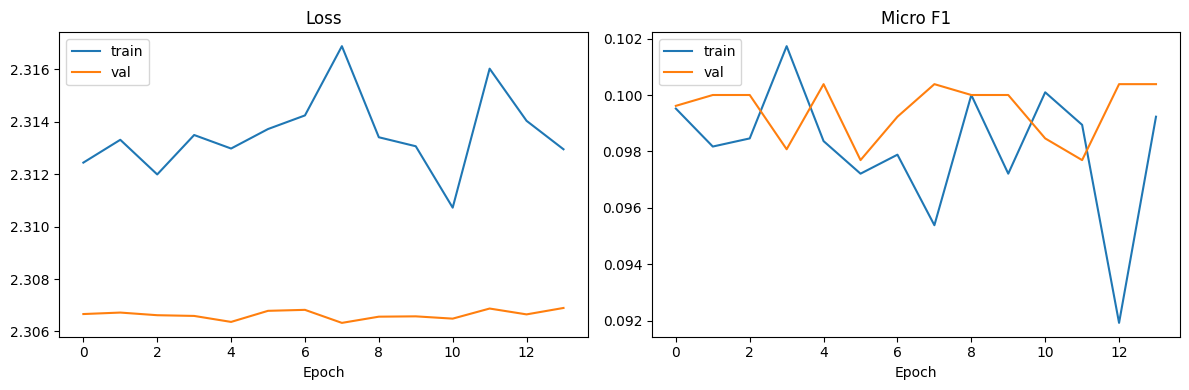

In [39]:

# model ,history_simpleCNN = train_model(model , trainloader, valloader, criterion, optimizer, scheduler,n_epochs=20, patience=7)

# plot_history(history_simpleCNN)

## ---> training CRNN

Epoch 01/20 | train_loss 2.3050 | train_f1 0.0948 | val_loss 2.3035 | val_f1 0.1035 | lr 7.81e-06 | no_improve 0/7
best model saved (val_loss=2.3035)
Epoch 02/20 | train_loss 2.3059 | train_f1 0.0955 | val_loss 2.3034 | val_f1 0.1035 | lr 7.81e-06 | no_improve 0/7
best model saved (val_loss=2.3034)
Epoch 03/20 | train_loss 2.3057 | train_f1 0.0959 | val_loss 2.3035 | val_f1 0.1035 | lr 7.81e-06 | no_improve 0/7
Epoch 04/20 | train_loss 2.3054 | train_f1 0.0938 | val_loss 2.3033 | val_f1 0.1035 | lr 3.91e-06 | no_improve 1/7
best model saved (val_loss=2.3033)
Epoch 05/20 | train_loss 2.3053 | train_f1 0.0969 | val_loss 2.3035 | val_f1 0.1035 | lr 3.91e-06 | no_improve 0/7
Epoch 06/20 | train_loss 2.3054 | train_f1 0.0951 | val_loss 2.3035 | val_f1 0.1035 | lr 3.91e-06 | no_improve 1/7
Epoch 07/20 | train_loss 2.3053 | train_f1 0.0922 | val_loss 2.3035 | val_f1 0.1035 | lr 3.91e-06 | no_improve 2/7
Epoch 08/20 | train_loss 2.3046 | train_f1 0.0959 | val_loss 2.3034 | val_f1 0.1035 | lr 1

epoch,▁▁▁▁▁▁▁▁▁▁▁
fold,▁▁▁▁▁▁▁▁▁▁▁
lr,███▃▃▃▃▁▁▁▁
train/f1_macro,▅▆▆▃█▅▁▆▇▆▃
train/loss,▃█▇▅▅▅▅▁▇▄▁
val/f1_macro,▁▁▁▁▁▁▁▁▁▁▁
val/loss,▇▃▄▁▆▅▄▃█▅▆
epoch,21
fold,1
lr,0.0
train/f1_macro,0.09327


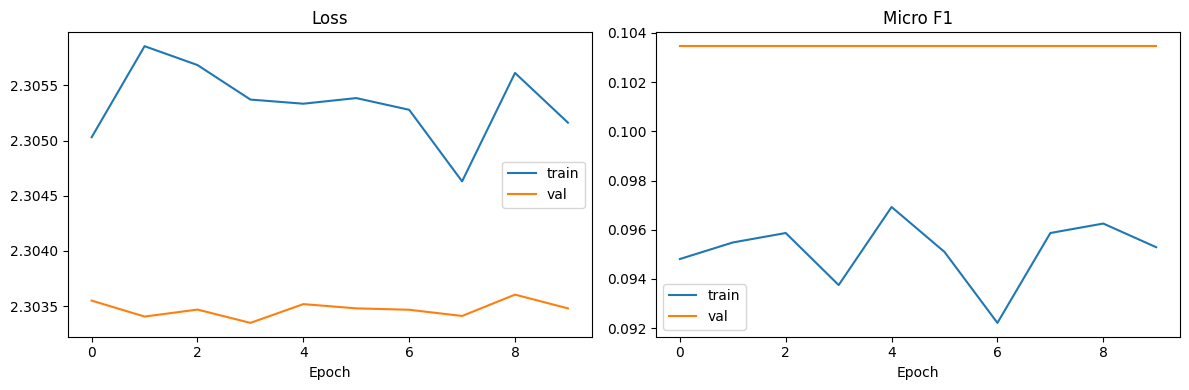

In [41]:
# model ,history_CRNN = train_model(model , trainloader, valloader, criterion, optimizer, scheduler,n_epochs=20, patience=7)

# plot_history(history_CRNN)

## ---> EfficientNetTransformer (Curriculum Learning)
Curriculum learning is a machine learning training technique where models are trained on data ordered by increasing difficulty, mimicking human education. By starting with simple examples and gradually introducing harder ones, this approach accelerates convergence, improves generalization, and helps avoid poor local minima in non-convex optimization problems.

Full model unfrozen
Epoch 01/20 | train_loss 0.4517 | train_f1 0.8473 | val_loss 0.6388 | val_f1 0.7986 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.6388)
Epoch 02/20 | train_loss 0.4215 | train_f1 0.8613 | val_loss 0.6197 | val_f1 0.8053 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.6197)
Epoch 03/20 | train_loss 0.3854 | train_f1 0.8738 | val_loss 0.6157 | val_f1 0.8117 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.6157)
Epoch 04/20 | train_loss 0.3635 | train_f1 0.8799 | val_loss 0.6058 | val_f1 0.8089 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.6058)
Epoch 05/20 | train_loss 0.3484 | train_f1 0.8853 | val_loss 0.6047 | val_f1 0.8121 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.6047)
Epoch 06/20 | train_loss 0.3398 | train_f1 0.8895 | val_loss 0.5903 | val_f1 0.8206 | lr 1.00e-05 | no_improve 0/7
  ✅ best model saved (val_loss=0.5903)
Epoch 07/20 | train_loss 0.3205 | train_f1 0.8957 | val_

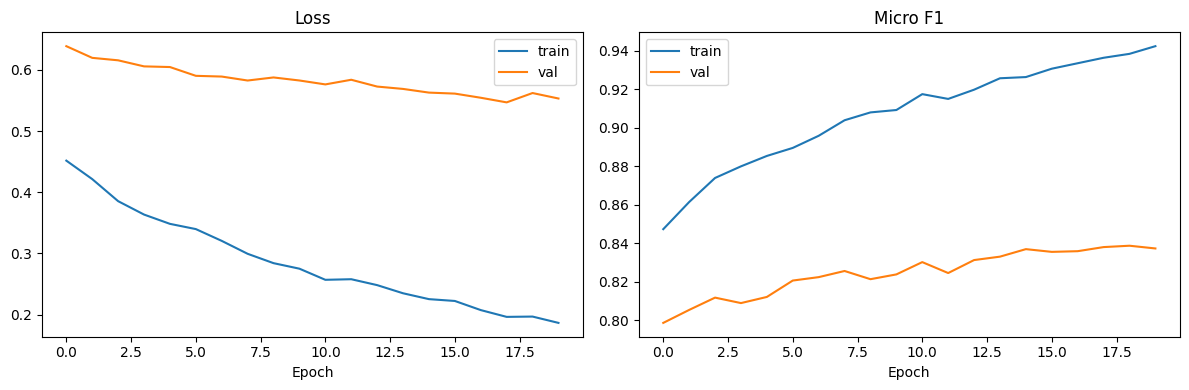

In [14]:
# =========================================================
# PHASE 1
# Train Transformer + Attention + Classifier
# =========================================================

# for param in model.cnn.parameters():
#     param.requires_grad = False

# print("EfficientNet frozen")


# optimizer = AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=3e-4,
#     weight_decay=1e-4
# )

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# # scheduler = ReduceLROnPlateau(optimizer, patience=3)

# # model ,h = train_model(model, trainloader, valloader, criterion, optimizer, scheduler,n_epochs=20, patience=7)
# model, h = train_model(model, trainloader, valloader, criterion, optimizer,
#                        scheduler,  n_epochs=10, patience=7)
# plot_history(h)


# =========================================================
# PHASE 2
# Unfreeze top EfficientNet layers
# =========================================================

# for param in model.cnn.parameters():
#     param.requires_grad = False

# # unfreeze last 2 blocks
# for layer in list(model.cnn.children())[-2:]:
#     for param in layer.parameters():
#         param.requires_grad = True

# print("Top EfficientNet blocks unfrozen")
# model.load_state_dict(torch.load("/kaggle/working/my_EfficientNetTransformer.pt", map_location=DEVICE))

# optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-4,weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# # scheduler = ReduceLROnPlateau(optimizer, patience=3)

# model, h = train_model(model, trainloader, valloader, criterion, optimizer,
#                        scheduler,  n_epochs=30, patience=7)
# plot_history(h)



# =========================================================
# PHASE 3
# Full model fine tuning
# =========================================================

for param in model.parameters():
    param.requires_grad = True

print("Full model unfrozen")

model.load_state_dict(torch.load("/kaggle/working/my_EfficientNetTransformer.pt", map_location=DEVICE))
optimizer = AdamW(model.parameters(),lr=1e-5,weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )


model, h = train_model(model, trainloader, valloader, criterion, optimizer,
                       scheduler, n_epochs=20, patience=7)
plot_history(h)


```
Stage 1 — Train Head Only head learns to make reasonable predictions first then

EfficientNet backbone    → FROZEN  (pretrained ImageNet knowledge preserved)
     ↓ passes features
Classifier head          → TRAINING (learning to map features → genres)

Goal: teach the head to interpret EfficientNet's features for genres
=========================================
Stage 2 — Unfreeze and Fine-tune, all parameters train but with very different learning rates

EfficientNet backbone    → FINE-TUNING  (slowly adapting to spectrograms)
     ↓
Classifier head          → TRAINING  (continuing to improve)

Goal: gently bend pretrained features toward audio/genre understanding
```

## Curriculum Learning 

```
Stage 1 — freeze backbone, clean data
    backbone = ImageNet weights (already good)
    only train the new classifier head
    head learns "what genre looks like"
    fast convergence, no risk of destroying pretrained weights
    lr=1e-3  - head only, learn fast

Stage 2 — unfreeze, same clean data
    now fine-tune entire model together
    clean data only - stable gradients
    backbone gently adapts to mel spectrograms
    no noise distraction while backbone is learning new domain
    lr=1e-5- full model, careful

Stage 3 — unfreeze, clean + noisy
    model already understands genres 
    backbone already adapted to mel 
    now teach noise robustness
    smaller lr - don't undo stage 2 learning
    lr=5e-6 - full model, more careful

Stage 4 — unfreeze, all data
    model already noise robust 
    now expose to hardest data (cross song)
    very small lr → fine adjustments only
    don't destroy anything learned so far
    lr=1e-6 - full model, very fine adjustments only
```

In [ ]:
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

# ══════════════════════════════════════════
# STAGE 1 — first conv + head only - clear
# ══════════════════════════════════════════
# print("STAGE 1 — first conv + head only")
# model     = GenreClassifier(freeze_backbone=True, unfreeze_top=0).to(DEVICE)
# optimizer = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=1e-3, weight_decay=1e-2
# )
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# model, h1 = train_model(model, trainloader, valloader, criterion, optimizer, scheduler,n_epochs=20, patience=7)
# torch.save(model.state_dict(), "/kaggle/working/model_s1.pt")
# ══════════════════════════════════════════
# STAGE 2 — first conv + top 2 + head - clear 
# ══════════════════════════════════════════
# print("STAGE 2 — first conv + top 2 + head")
# model     = GenreClassifier(freeze_backbone=True, unfreeze_top=2).to(DEVICE)

# optimizer = torch.optim.AdamW([
#     {"params": model.backbone.features[0][0].parameters(), "lr": 1e-4},  # first conv
#     {"params": model.backbone.features[7].parameters(),    "lr": 1e-5},  # top 2
#     {"params": model.backbone.features[8].parameters(),    "lr": 1e-5},
#     {"params": model.backbone.classifier.parameters(),     "lr": 1e-4},  # head
# ], weight_decay=1e-2)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# model, h2 = train_model(model, trainloader, valloader, criterion, optimizer, scheduler,n_epochs=40, patience=7)
# torch.save(model.state_dict(), "/kaggle/working/model_s2.pt")

# ══════════════════════════════════════════
# STAGE 3 — first conv + top 4 + head
# ══════════════════════════════════════════
# print("STAGE 3 — first conv + top 4 + head")
# model     = GenreClassifier(freeze_backbone=True, unfreeze_top=4).to(DEVICE)

# optimizer = torch.optim.AdamW([
#     {"params": model.backbone.features[0][0].parameters(), "lr": 5e-5},  # first conv
#     {"params": model.backbone.features[5].parameters(),"lr": 5e-6},  # top 4
#     {"params": model.backbone.features[6].parameters(),"lr": 5e-6},
#     {"params": model.backbone.features[7].parameters(),"lr": 1e-5},
#     {"params": model.backbone.features[8].parameters(),"lr": 1e-5},
#     {"params": model.backbone.classifier.parameters(),"lr": 5e-5},  # head
# ], weight_decay=1e-2)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# model, h3 = train_model(model,modelname="EfficientNet_B0", trainloader, valloader,criterion, optimizer, scheduler,n_epochs=40, patience=7)


# ══════════════════════════════════════════
# STAGE 4 — all layers
# ══════════════════════════════════════════
# print("STAGE 4 — all layers")
# model     = GenreClassifier(freeze_backbone=False).to(DEVICE)
# # model.load_state_dict(torch.load("/kaggle/working/my_EfficientNet_B0.pt"))

# optimizer = torch.optim.AdamW([
#     {"params": model.backbone.features.parameters(),   "lr": 1e-6},  
#     {"params": model.backbone.classifier.parameters(), "lr": 1e-5},
# ], weight_decay=1e-2)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, "min", factor=0.5, patience=3  )
# model, h4 = train_model(model,modelname="EfficientNet_B0", trainloader, valloader,criterion, optimizer, scheduler,n_epochs=60, patience=7)




# plot_history(h1)
# plot_history(h2)
# plot_history(h3)
# plot_history(h4)

# ============= Uploading model to kagglehub ================

In [4]:
# model = HybridModel()
# model_path = f"/kaggle/working/fold2_best.pth"


modelname= model.__class__.__name__


import kagglehub, os, torch

KAGGLE_USERNAME = "satyabratachowdhury"
MODEL = modelname          
FRAMEWORK = "pytorch"
VARIATION = "genre_model"     

handle = f"{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}"


model_path = f"my_{modelname}.pt"


# Upload === > commented
kagglehub.model_upload( handle,model_path ,version_notes="genre_model")    # on/off

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Uploading Model https://api.kaggle.com/models/satyabratachowdhury/HybridModel/pytorch/genre_model ...
Model 'HybridModel' does not exist or access is forbidden for user 'satyabratachowdhury'. Creating or handling Model...
Model 'HybridModel' Created.
Starting upload for file /kaggle/working/fold2_best.pth


Uploading: 100%|██████████| 346M/346M [00:13<00:00, 26.4MB/s] 

Upload successful: /kaggle/working/fold2_best.pth (330MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/satyabratachowdhury/HybridModel/pytorch/genre_model


## Load the uploaded model from kagglehub

In [5]:
import kagglehub
import torch

# To download from kagglehub
path = kagglehub.model_download( "satyabratachowdhury/EfficientNet_B0/pytorch/genre_model")
print(f"Downloaded to: {path}")   # prints exact folder path

model = GenreClassifier(n_classes=len(label_genre_map)).to(DEVICE)    # on/off

model.load_state_dict(torch.load(os.path.join(path, "my_EfficientNet_B0.pt"), map_location=DEVICE))  # on/off

print("Model loaded SUCCESSFULY ")

Mounting files to /kaggle/input/models/satyabratachowdhury/efficientnet_b0/pytorch/genre_model/14...
Downloaded to: /kaggle/input/models/satyabratachowdhury/efficientnet_b0/pytorch/genre_model/14
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 181MB/s]


Model loaded SUCCESSFULY 


## Test Prediction/Inference to create the submission CSV

In [16]:
from collections import Counter


genre_map = {0:'blues', 1:'classical', 2:'country', 3:'disco', 4:'hiphop', 5:'jazz', 6:'metal', 7:'pop', 8:'reggae', 9:'rock'}



def load_and_chunk(audio_path):
    """
    Works for ANY duration — 6s, 15s, 30s, anything.
    Always returns list of (1, 128, 216) mel specs.
    """
    # Load
    waveform, sr = torchaudio.load(audio_path)

    # Resample if needed
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    waveform = waveform.to(DEVICE)
    length   = waveform.shape[1]

    mel_chunks = []

    # ---------- if Audio is shorter than 5s then pad and use as single chunk
    if length < CHUNK_SIZE:
        pad = CHUNK_SIZE - length
        waveform = torch.nn.functional.pad(waveform, (0, pad))
        mel_chunks.append(chunk_to_melspec(waveform))

    # ---------- if Audio is between 5s and 10s ,that may only give 1-2 chunks
    # ---------- if Audio is 30s > gives ~12 chunks
    # Both handled by the same sliding window below
    else:
        for start in range(0, length - CHUNK_SIZE + 1, HOP_SIZE):
            chunk = waveform[:, start : start + CHUNK_SIZE]
            mel_chunks.append(chunk_to_melspec(chunk))

        # leftover sound (last few seconds after final full chunk)
        tail_start = len(mel_chunks) * HOP_SIZE
        tail = waveform[:, tail_start:]
        if tail.shape[1] > SAMPLE_RATE:         # only if tail > 1 second
            pad = CHUNK_SIZE - tail.shape[1] % CHUNK_SIZE
            tail = torch.nn.functional.pad(tail, (0, pad))
            mel_chunks.append(chunk_to_melspec(tail[:, :CHUNK_SIZE]))

    return mel_chunks  # list of (1, 128, 216) tensors , always same shape



def predict(audio_path, model, genre_map):
    """
    genre_map: {0: 'blues', 1: 'classical', ...}
    Works for any audio length.
    """
    model.eval()
    mel_chunks = load_and_chunk(audio_path)   # list of (1, 128, 216)

    chunk_preds = []
    with torch.no_grad():
        for mel in mel_chunks:
            mel  = mel.to(DEVICE)
            out  = model(mel.unsqueeze(0))     # (1, 1, 128, 216) → (1, 10)
            pred = out.argmax(dim=-1).item()
            chunk_preds.append(pred)
            # print(out, pred, chunk_preds,"\n\n")

    # Majority vote
    final = Counter(chunk_preds).most_common(1)[0][0]
    return genre_map[final]




In [118]:
add="/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/song0028.wav"
pred = predict(add, model, genre_map)
print(f"Predicted genre: {pred}")
Audio(add, rate=SAMPLE_RATE)

Predicted genre: disco


# create submission

In [17]:
for i,row in test.iterrows():
    
    pred = predict(os.path.join("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup",row["filename"]), model, genre_map)
    
    sample_submission.iloc[i,1] = pred

print("done")
sample_submission


done


,id,genre
0,1,pop
1,2,classical
2,3,reggae
3,4,metal
4,5,country
...,...,...
3015,3016,rock
3016,3017,jazz
3017,3018,reggae
3018,3019,country


In [18]:
sample_submission.to_csv('submission.csv', index=False)
print("Sample submission completed")

Sample submission completed


# ================== cutoff =================Gp

# AST (Audio Spectrogram Transformer)

In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchaudio
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from transformers import ASTForAudioClassification, ASTFeatureExtractor
import kagglehub
import wandb

warnings.filterwarnings("ignore")

# ===================== CONFIG =====================

DATA_DIR = Path("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup")
STEMS_DIR = DATA_DIR / "genres_stems"
ESC50_DIR = DATA_DIR / "ESC-50-master" / "audio"

SR = 16000
CLIP_DURATION = 10
CLIP_LEN = SR * CLIP_DURATION

SEGMENTS_PER_CLIP = 5
SEG_LEN = CLIP_LEN // SEGMENTS_PER_CLIP

FOLDS = 3
EPOCHS = 16
BATCH_SIZE = 12
LR = 3e-5
WEIGHT_DECAY = 1e-2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2

NOISE_AUG_PROB = 0.7
MIN_SNR_DB = 0
MAX_SNR_DB = 20
NOISE_GAIN_RANGE = (0.1, 0.4)

GENRES = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]

GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}

MODEL_HUB_PATH = "satyabratachowdhury/segment_ast_t4/pytorch/v1"

feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

# ===================== AUDIO =====================

def load_audio(path, target_sr=SR):
    y, sr = torchaudio.load(path)
    if sr != target_sr:
        y = torchaudio.functional.resample(y, sr, target_sr)
    return y.mean(0)


def normalize_audio(waveform, peak=0.95):
    if isinstance(waveform, np.ndarray):
        waveform = torch.from_numpy(waveform)

    m = waveform.abs().max()
    if m > 1e-8:
        waveform = waveform / m * peak
    return waveform


def mix_noise(clean, noise, snr_db):
    if isinstance(clean, np.ndarray):
        clean = torch.from_numpy(clean)
    if isinstance(noise, np.ndarray):
        noise = torch.from_numpy(noise)

    clean_power = (clean ** 2).mean() + 1e-8
    snr = 10 ** (snr_db / 10)
    noise_power = clean_power / snr

    scale = torch.sqrt(noise_power / ((noise ** 2).mean() + 1e-8))
    noise = noise * scale * random.uniform(*NOISE_GAIN_RANGE)

    return normalize_audio(clean + noise)


def augment_with_noise(waveform, noise_cache):
    if not noise_cache or random.random() > NOISE_AUG_PROB:
        return waveform.numpy()

    noise = torch.from_numpy(random.choice(noise_cache)).float()
    target_len = len(waveform)

    if len(noise) < target_len:
        noise = noise.repeat(int(np.ceil(target_len / len(noise))))[:target_len]
    else:
        start = random.randint(0, max(0, len(noise) - target_len))
        noise = noise[start:start + target_len]

    snr = random.uniform(MIN_SNR_DB, MAX_SNR_DB)
    return mix_noise(waveform, noise, snr).numpy()

# ==========
# def augment_audio(waveform, noise_cache):
#     x = waveform.clone()

#     # ================= NOISE =================
#     if noise_cache and random.random() < NOISE_AUG_PROB:
#         noise = torch.from_numpy(random.choice(noise_cache)).float()
#         target_len = len(x)

#         if len(noise) < target_len:
#             noise = noise.repeat(int(np.ceil(target_len / len(noise))))[:target_len]
#         else:
#             start = random.randint(0, len(noise) - target_len)
#             noise = noise[start:start + target_len]

#         snr = random.uniform(MIN_SNR_DB, MAX_SNR_DB)

#         sp = x.pow(2).mean()
#         npow = noise.pow(2).mean()
#         scale = torch.sqrt(sp / (npow * (10**(snr/10)) + 1e-8))

#         x = x + scale * noise

#     # ================= TIME SHIFT =================
#     if random.random() < 0.5:
#         shift = random.randint(-len(x)//10, len(x)//10)
#         x = torch.roll(x, shifts=shift)

#     # ================= GAIN (volume change) =================
#     if random.random() < 0.5:
#         gain = random.uniform(0.7, 1.3)
#         x = x * gain

#     # ================= TIME STRETCH =================
#     if random.random() < 0.3:
#         rate = random.uniform(0.9, 1.1)
#         idx = torch.linspace(0, len(x)-1, int(len(x)/rate)).long()
#         x = x[idx]

#         # pad or trim
#         if len(x) < len(waveform):
#             x = F.pad(x, (0, len(waveform) - len(x)))
#         else:
#             x = x[:len(waveform)]

#     # ================= RANDOM DROPOUT =================
#     if random.random() < 0.3:
#         drop_len = random.randint(0, len(x)//10)
#         start = random.randint(0, len(x) - drop_len)
#         x[start:start+drop_len] = 0

#     # ================= CLIPPING DISTORTION =================
#     if random.random() < 0.3:
#         clip_val = random.uniform(0.5, 1.0)
#         x = torch.clamp(x, -clip_val, clip_val)

#     return x.numpy()

# ===================== PRELOAD =====================

def preload_clean_dataset():
    audio_cache, labels = [], []

    print("Loading training audio...")

    for genre in GENRES:
        base = STEMS_DIR / genre
        if not base.exists():
            continue

        for folder in tqdm(list(base.glob("*")), desc=genre):
            if not folder.is_dir():
                continue

            mix = torch.zeros(CLIP_LEN)

            for stem in ["drums.wav","bass.wav","vocals.wav","others.wav"]:
                p = folder / stem
                if p.exists():
                    y = load_audio(p)
                    y = y[:CLIP_LEN] if len(y) >= CLIP_LEN else F.pad(y, (0, CLIP_LEN - len(y)))
                    mix += y

            audio_cache.append(normalize_audio(mix).numpy())
            labels.append(GENRE2IDX[genre])

    print(f"Loaded {len(audio_cache)} samples")
    return audio_cache, labels


def preload_noise_samples(limit=100):
    path = Path(ESC50_DIR)
    if not path.exists():
        return []

    files = list(path.rglob("*.wav"))
    files = random.sample(files, min(len(files), limit))

    noise_cache = []
    for f in tqdm(files, desc="noise"):
        try:
            noise_cache.append(normalize_audio(load_audio(f)).numpy())
        except:
            pass

    print(f"Loaded {len(noise_cache)} noise samples")
    return noise_cache

# ===================== DATASET =====================

class SegmentDataset(Dataset):
    def __init__(self, audio, labels, noise=None, train=True):
        self.audio = audio
        self.labels = labels
        self.noise = noise
        self.train = train

    def __len__(self):
        return len(self.audio) * SEGMENTS_PER_CLIP

    def __getitem__(self, idx):
        i = idx // SEGMENTS_PER_CLIP
        s = idx % SEGMENTS_PER_CLIP

        wave = torch.from_numpy(self.audio[i]).float()
        seg = wave[s*SEG_LEN:(s+1)*SEG_LEN]

        if self.train:
            seg = torch.from_numpy(augment_with_noise(seg, self.noise)).float()

        inputs = feature_extractor(seg.numpy(), sampling_rate=SR, return_tensors="pt")

        return inputs.input_values.squeeze(0), torch.tensor(self.labels[i])

# ===================== MODEL =====================




def build_model():
    model = ASTForAudioClassification.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593",
        num_labels=len(GENRES),
        ignore_mismatched_sizes=True
    )
    return model.to(DEVICE)

# ===================== METRICS =====================

def compute_metrics(preds, targets):
    f1_macro = f1_score(targets, preds, average="macro", zero_division=0)
    f1_weighted = f1_score(targets, preds, average="weighted", zero_division=0)
    acc = (np.array(preds) == np.array(targets)).mean()
    return f1_macro, f1_weighted, acc

# ===================== TRAIN =====================

def train_pipeline():
    # wandb.init(project="22F3003016-t12026", name="AST")

    audio, labels = preload_clean_dataset()
    noise = preload_noise_samples()

    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

    for fold, (tr, va) in enumerate(skf.split(audio, labels)):
        print(f"\n Fold {fold+1}")

        train_ds = SegmentDataset([audio[i] for i in tr], [labels[i] for i in tr], noise, True)
        val_ds = SegmentDataset([audio[i] for i in va], [labels[i] for i in va], None, False)

        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

        model = build_model()
        opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * len(train_dl))
        scaler = GradScaler()

        best = 0

        for ep in range(EPOCHS):
            model.train()
            tr_preds, tr_targets = [], []

            for xb, yb in tqdm(train_dl, leave=False):
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                opt.zero_grad()

                with autocast():
                    out = model(input_values=xb)
                    loss = F.cross_entropy(out.logits, yb)

                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                sched.step()

                tr_preds.extend(out.logits.argmax(1).cpu().numpy())
                tr_targets.extend(yb.cpu().numpy())

            train_f1 = f1_score(tr_targets, tr_preds, average="macro")

            model.eval()
            va_preds, va_targets = [], []

            with torch.no_grad():
                for xb, yb in val_dl:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    out = model(input_values=xb)
                    va_preds.extend(out.logits.argmax(1).cpu().numpy())
                    va_targets.extend(yb.cpu().numpy())

            val_f1 = f1_score(va_targets, va_preds, average="macro")

            print(f"ep {ep+1} | train {train_f1:.4f} | val {val_f1:.4f}")

            # wandb.log({"fold": fold, "epoch": ep, "train_f1": train_f1, "val_f1": val_f1})

            if val_f1 > best:
                best = val_f1
                torch.save(model.state_dict(), f"model_fold{fold}.pth")

        torch.cuda.empty_cache()

    # wandb.finish()


# ===================== INFERENCE =====================

@torch.no_grad()
def inference_pipeline():
    models = []

    for f in sorted(Path(".").glob("model_fold*.pth")):
        m = build_model()
        m.load_state_dict(torch.load(f, map_location=DEVICE))
        m.eval()
        models.append(m)

    test_df = pd.read_csv(DATA_DIR / "test.csv")
    sample = pd.read_csv(DATA_DIR / "sample_submission.csv")

    preds = []

    for fname in tqdm(test_df["filename"]):
        path = DATA_DIR / fname
        y = load_audio(path)

        y = y[:CLIP_LEN] if len(y) >= CLIP_LEN else F.pad(y, (0, CLIP_LEN - len(y)))

        segs = [y[i*SEG_LEN:(i+1)*SEG_LEN].numpy() for i in range(SEGMENTS_PER_CLIP)]

        inputs = feature_extractor(segs, sampling_rate=SR, return_tensors="pt")
        xb = inputs.input_values.to(DEVICE)

        logits = []
        for m in models:
            logits.append(m(input_values=xb).logits)

        logits = torch.stack(logits).mean(0).mean(0)

        preds.append(IDX2GENRE[logits.argmax().item()])

    sub = pd.DataFrame({"id": sample["id"], "genre": preds})
    sub.to_csv("submission.csv", index=False)
    print("submission.csv ready")


# ===================== RUN =====================

if __name__ == "__main__":
    train_pipeline()
    inference_pipeline()

In [3]:
import os, random, re, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from transformers import get_cosine_schedule_with_warmup

import torchaudio
import librosa

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from transformers import ASTModel, ASTFeatureExtractor

warnings.filterwarnings("ignore")

# ===================== CONFIG =====================
DATA_DIR = Path("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup")
STEMS_DIR = DATA_DIR / "genres_stems"
MASHUPS_DIR = DATA_DIR / "mashups"
ESC50_DIR = DATA_DIR / "ESC-50-master" / "audio"

SR = 16000
CLIP_DURATION = 10
CLIP_LEN = SR * CLIP_DURATION

SEGMENTS = 5
SEG_LEN = CLIP_LEN // SEGMENTS

EPOCHS = 12
BATCH_SIZE = 24 # 12
LR = 5e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GENRES = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
g2i = {g:i for i,g in enumerate(GENRES)}
i2g = {i:g for g,i in g2i.items()}

# feature_extractor = ASTFeatureExtractor.from_pretrained(
#     "MIT/ast-finetuned-audioset-10-10-0.4593"
# )
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    mean=0,
    std=0.5
)

# ===================== AUDIO =====================
def load_audio(path):
    y, sr = torchaudio.load(path)
    if sr != SR:
        y = torchaudio.functional.resample(y, sr, SR)
    y = y.mean(0)

    if len(y) < CLIP_LEN:
        y = F.pad(y, (0, CLIP_LEN - len(y)))
    return y[:CLIP_LEN]


def normalize(x):
    peak = x.abs().max()
    return x / peak if peak > 0 else x


# def extract_mfcc(y):
#     y = y.numpy()
#     mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13)
#     return torch.tensor(np.mean(mfcc, axis=1), dtype=torch.float32)


# ===================== PRELOAD =====================
# def preload():
#     audio, labels = [], []

#     for genre in GENRES:
#         base = STEMS_DIR / genre
#         for folder in base.glob("*"):
#             if not folder.is_dir():
#                 continue

#             mix = torch.zeros(CLIP_LEN)

#             for stem in ["drums.wav","bass.wav","vocals.wav","others.wav"]:
#                 p = folder / stem
#                 if p.exists():
#                     mix += load_audio(p)

#             audio.append(normalize(mix).numpy())
#             labels.append(g2i[genre])

#     return audio, labels
def preload():
    paths, labels = [], []

    for genre in GENRES:
        base = STEMS_DIR / genre
        for folder in base.glob("*"):
            if not folder.is_dir():
                continue

            paths.append(folder)
            labels.append(g2i[genre])

    return paths, labels

def load_noise(limit=80):
    files = list(Path(ESC50_DIR).rglob("*.wav"))
    files = random.sample(files, min(len(files), limit))

    noise = []
    for f in files:
        try:
            noise.append(normalize(load_audio(f)).numpy())
        except:
            pass
    return noise


# ===================== DATASET =====================
# class SegmentDataset(Dataset):
#     def __init__(self, audio, labels, noise=None, train=True):
#         self.audio = audio
#         self.labels = labels
#         self.noise = noise
#         self.train = train

#     def __len__(self):
#         return len(self.audio) * SEGMENTS

    
#     def __getitem__(self, idx):
#         i = idx // SEGMENTS
#         s = idx % SEGMENTS

#         wave = torch.tensor(self.audio[i])
#         # seg = wave[s*SEG_LEN:(s+1)*SEG_LEN]
#         start = random.randint(0, len(wave) - SEG_LEN)
#         seg = wave[start:start+SEG_LEN]

#         if self.train and self.noise and random.random() < 0.6:
#             n = torch.tensor(random.choice(self.noise))
#             # seg = seg + 0.2 * n[:len(seg)]
#             snr = random.uniform(5, 20)

#             sp = seg.pow(2).mean()
#             npow = n.pow(2).mean()
            
#             scale = torch.sqrt(sp / (npow * (10**(snr/10)) + 1e-8))
#             seg = seg + scale * n[:len(seg)]

#         # seg = normalize(seg)
        
#         # waveform normalization (AST recommended)
#         seg = (seg - seg.mean()) / (seg.std() + 1e-6)
#         seg = normalize(seg)

#         # ast = feature_extractor(seg.numpy(), sampling_rate=SR, return_tensors="pt")
#         # mfcc = extract_mfcc(seg)

#         # return ast.input_values.squeeze(0), mfcc, self.labels[i]
#         ast = feature_extractor(seg.numpy(), sampling_rate=SR, return_tensors="pt")

#         x = ast.input_values.squeeze(0)

        
#         if self.train:
#             # time mask
#             t = random.randint(0, x.shape[1] // 8)
#             t0 = random.randint(0, x.shape[1] - t)
#             x[:, t0:t0 + t] = 0
        
#             # freq mask
#             f = random.randint(0, x.shape[0] // 8)
#             f0 = random.randint(0, x.shape[0] - f)
#             x[f0:f0 + f, :] = 0

        
#         # return ast.input_values.squeeze(0), self.labels[i]
#         return x, self.labels[i]
class SegmentDataset(Dataset):
    def __init__(self, paths, labels, noise=None, train=True):
        self.paths = paths      # folders now
        self.labels = labels
        self.noise = noise
        self.train = train

    def __len__(self):
        return len(self.paths) * SEGMENTS

    def __getitem__(self, idx):
        i = idx // SEGMENTS
        s = idx % SEGMENTS

        folder = self.paths[i]

        # ================= LOAD + MIX STEMS =================
        mix = torch.zeros(CLIP_LEN)

        for stem in ["drums.wav", "bass.wav", "vocals.wav", "others.wav"]:
            p = folder / stem
            if p.exists():
                mix += load_audio(p)

        wave = normalize(mix)

        # ================= RANDOM CROP =================
        start = random.randint(0, CLIP_LEN - SEG_LEN)
        seg = wave[start:start + SEG_LEN]

        # ================= NOISE AUG =================
        if self.train and self.noise and random.random() < 0.6:
            n = torch.tensor(random.choice(self.noise))

            # ensure same length
            if len(n) < len(seg):
                n = n.repeat(int(np.ceil(len(seg)/len(n))))[:len(seg)]
            else:
                start_n = random.randint(0, len(n) - len(seg))
                n = n[start_n:start_n+len(seg)]

            snr = random.uniform(5, 20)

            sp = seg.pow(2).mean()
            npow = n.pow(2).mean()

            scale = torch.sqrt(sp / (npow * (10**(snr/10)) + 1e-8))
            seg = seg + scale * n

        # ================= NORMALIZATION =================
        seg = (seg - seg.mean()) / (seg.std() + 1e-6)
        seg = normalize(seg)

        # ================= AST FEATURE =================
        ast = feature_extractor(
            seg.numpy(),
            sampling_rate=SR,
            return_tensors="pt"
        )

        x = ast.input_values.squeeze(0)

        # ================= SPEC AUG =================
        if self.train:
            # time mask
            t = random.randint(0, x.shape[1] // 8)
            t0 = random.randint(0, x.shape[1] - t)
            x[:, t0:t0 + t] = 0

            # freq mask
            f = random.randint(0, x.shape[0] // 8)
            f0 = random.randint(0, x.shape[0] - f)
            x[f0:f0 + f, :] = 0

        return x, self.labels[i]


# ===================== MODEL =====================
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.ast = ASTModel.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593"
        )

        for p in self.ast.parameters():
            p.requires_grad = False

        for layer in self.ast.encoder.layer[-2:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.head = nn.Sequential(
            # nn.Linear(768 + 13, 256),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, len(GENRES))
        )

    # def forward(self, x, mfcc):
    #     out = self.ast(input_values=x)
    #     cls = out.last_hidden_state[:, 0]
    #     return self.head(torch.cat([cls, mfcc], dim=1))
    def forward(self, x):
        out = self.ast(input_values=x)
        # cls = out.last_hidden_state[:, 0]
        cls = out.last_hidden_state.mean(dim=1)
        return self.head(cls)


# ===================== TRAIN =====================
def train():
    # --- W&B INIT ---
    wandb.init(
        project="22F3003016-t12026",
        entity="22F3003016-dl-genai-project",
        
        # name="hybrid_ast_mfcc",
        name="modified_AST",
        config={
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "segments": SEGMENTS,
            "sr": SR,
            "clip_duration": CLIP_DURATION
        }
    )
  
    audio, labels = preload()
    noise = load_noise()

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for fold, (tr, va) in enumerate(skf.split(audio, labels)):
        print(f"\n--- Fold {fold+1} ---")

        train_ds = SegmentDataset([audio[i] for i in tr], [labels[i] for i in tr], noise, True)
        val_ds = SegmentDataset([audio[i] for i in va], [labels[i] for i in va], None, False)

        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,num_workers=4,pin_memory=True, shuffle=True)
        val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE,num_workers=4,pin_memory=True)

        model = HybridModel().to(DEVICE)
        # opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
        opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5,  weight_decay=1e-4)
        

        total_steps = len(train_dl) * EPOCHS
        warmup_steps = int(0.1 * total_steps)
        
        scheduler = get_cosine_schedule_with_warmup(
                                                    opt,
                                                    num_warmup_steps=warmup_steps,
                                                    num_training_steps=total_steps
                                                )
        
        scaler = GradScaler()

        
        best = 0
        counter = 0
        
        patience = 3         
        lr_patience = 2     
        lr_factor = 0.5     
        
        min_lr = 1e-7
        lr_reduce_count = 0


        for ep in range(EPOCHS):
            model.train()
            preds, targs = [], []

            # for x, mfcc, y in tqdm(train_dl, leave=False):
            for x, y in tqdm(train_dl):
                # x, mfcc, y = x.to(DEVICE), mfcc.to(DEVICE), y.to(DEVICE)
                x, y = x.to(DEVICE), y.to(DEVICE)

                opt.zero_grad()

                with autocast():
                    # out = model(x, mfcc)
                    out = model(x)
                    loss = F.cross_entropy(out, y,label_smoothing=0.1)

                # scaler.scale(loss).backward()
                # scaler.step(opt)
                # scaler.update()
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                
                scaler.step(opt)
                scaler.update()
                scheduler.step()

                preds.extend(out.argmax(1).cpu().numpy())
                targs.extend(y.cpu().numpy())

            train_f1 = f1_score(targs, preds, average='macro')

            model.eval()
            preds, targs = [], []

            with torch.no_grad():
                # for x, mfcc, y in val_dl:
                for x, y in val_dl:
                    # x, mfcc, y = x.to(DEVICE), mfcc.to(DEVICE), y.to(DEVICE)
                    # out = model(x, mfcc)
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    out = model(x)

                    preds.extend(out.argmax(1).cpu().numpy())
                    targs.extend(y.cpu().numpy())

            val_f1 = f1_score(targs, preds, average='macro')

            print(f"ep {ep+1} | train {train_f1:.4f} | val {val_f1:.4f}")
            # ---------- W&B LOG ----------
            wandb.log({
                "fold": fold,
                "epoch": ep + 1,
                "train_f1": train_f1,
                "val_f1": val_f1,
                "lr": opt.param_groups[0]["lr"]
            })

            # ---------- CHECKPOINT ----------
            # if val_f1 > best:
            #     best = val_f1

            #     ckpt = {
            #         "model": model.state_dict(),
            #         "fold": fold,
            #         "epoch": ep,
            #         "best_f1": best
            #     }

            #     torch.save(ckpt, f"fold{fold}_best.pth")
            #     print(f"saved best model (fold {fold}) | f1={best:.4f}")
            if val_f1 > best + 1e-4:
                best = val_f1
                counter = 0
            
                # torch.save(model.state_dict(), "best.pth")
                ckpt = {
                    "model": model.state_dict(),
                    "fold": fold,
                    "epoch": ep,
                    "best_f1": best
                }

                torch.save(ckpt, f"fold{fold}_best.pth")
                print(f"saved best model (fold {fold}) | f1={best:.4f}")
                wandb.log({f"best_f1_fold_{fold}": best})
            
            else:
                counter += 1
                print(f"No improvement: {counter}/{patience}")

            if counter >= patience:
    
                if lr_reduce_count < lr_patience:
                    print(" Reducing the Learning Rate")
            
                    for g in opt.param_groups:
                        g['lr'] = max(g['lr'] * lr_factor, min_lr)
            
                    lr_reduce_count += 1
                    counter = 0   # reset counter
            
                else:
                    print("Early stopping triggered")
                    break
        # optional last checkpoint
        torch.save(model.state_dict(), f"fold{fold}_last.pth")

    wandb.finish()

            # XXXXXXXXXXXXXXXXXXXXXXXXXX w&b loging
            # wandb.log({
            #     "fold": fold + 1,
            #     "epoch": epoch + 1,
            #     "train/loss": train_loss,
            #     "val/loss": val_loss,
            #     "train/f1_macro": train_metrics["f1_macro"],
            #     "val/f1_macro": val_metrics["f1_macro"],
            #     "val/f1_weighted": val_metrics["f1_weighted"],
            #     "val/accuracy": val_metrics["accuracy"],
            #     "lr": scheduler.get_last_lr()[0],
            # })

            # if val_f1 > best:
            #     best = val_f1
            #     torch.save(model.state_dict(), f"fold{fold}.pth")
    # wandb.finish()


# # ===================== INFERENCE =====================
# @torch.no_grad()
# def inference():
#     models = []
#     # for f in sorted(Path(".").glob("fold*.pth")):
#     #     m = HybridModel().to(DEVICE)
#     #     m.load_state_dict(torch.load(f, map_location=DEVICE))
#     #     m.eval()
#     #     models.append(m)
#     for f in sorted(Path(".").glob("fold*_best.pth")):
#         m = HybridModel().to(DEVICE)
#         ckpt = torch.load(f, map_location=DEVICE)
#         m.load_state_dict(ckpt["model"])
#         m.eval()
#         models.append(m)

#     test_df = pd.read_csv(DATA_DIR / "test.csv")

#     preds = []

#     for fname in tqdm(test_df["filename"]):
#         y = load_audio(DATA_DIR / fname)

#         segs = [y[i*SEG_LEN:(i+1)*SEG_LEN] for i in range(SEGMENTS)]

#         inputs = feature_extractor([s.numpy() for s in segs], sampling_rate=SR, return_tensors="pt")
#         x = inputs.input_values.to(DEVICE)

#         # mfcc = torch.stack([extract_mfcc(s) for s in segs]).to(DEVICE)

#         logits = []

#         for m in models:
#             # out = m(x, mfcc)
#             out = m(x)
#             logits.append(out)

#         logits = torch.stack(logits).mean(0).mean(0)
#         preds.append(i2g[logits.argmax().item()])

#     sub =pd.DataFrame({"id": test_df["id"], "genre": preds})
#     sub.to_csv("submission.csv", index=False)
#     print("submission.csv ready")
@torch.no_grad()
def inference():
    models = []

    # ================= LOAD BEST MODELS =================
    for f in sorted(Path(".").glob("fold*_best.pth")):
        m = HybridModel().to(DEVICE)
        ckpt = torch.load(f, map_location=DEVICE)
        m.load_state_dict(ckpt["model"])
        m.eval()
        models.append(m)

    print(f"Loaded {len(models)} models")

    # ================= LOAD TEST DATA =================
    test_df = pd.read_csv(DATA_DIR / "test.csv")
    preds = []

    # ================= INFERENCE =================
    for fname in tqdm(test_df["filename"]):
        y = load_audio(DATA_DIR / fname)

        tta_logits = []

        #  TTA LOOP (multiple random crops)
        for _ in range(3):  
            segs = []

            for _ in range(SEGMENTS):
                start = random.randint(0, len(y) - SEG_LEN)
                seg = y[start:start+SEG_LEN]

                # SAME normalization as training
                seg = (seg - seg.mean()) / (seg.std() + 1e-6)

                segs.append(seg.numpy())

            inputs = feature_extractor(
                segs,
                sampling_rate=SR,
                return_tensors="pt"
            )

            x = inputs.input_values.to(DEVICE)

            # ================= MODEL ENSEMBLE =================
            fold_logits = []

            for m in models:
                out = m(x)  # shape: [segments, num_classes]
                fold_logits.append(out)

            # [num_models, segments, classes]
            fold_logits = torch.stack(fold_logits)

            # average across models + segments
            fold_logits = fold_logits.mean(0).mean(0)

            tta_logits.append(fold_logits)

        # ================= FINAL PRED =================
        final_logits = torch.stack(tta_logits).mean(0)

        preds.append(i2g[final_logits.argmax().item()])

    # ================= SAVE SUBMISSION =================
    sub = pd.DataFrame({
        "id": test_df["id"],
        "genre": preds
    })

    sub.to_csv("submission.csv", index=False)
    print(" submission.csv ready")

# ===================== RUN =====================
if __name__ == "__main__":
    train()
    inference()

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]


--- Fold 1 ---


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded 3 models


100%|██████████| 3020/3020 [4:00:27<00:00,  4.78s/it]  

 submission.csv ready


In [4]:
# submission.to_csv("submission.csv", index=False)

# ========================== experiments =======================

In [1]:
SEGMENTS = 5
audio_len = 3

for idx in range(audio_len * SEGMENTS):
    i = idx // SEGMENTS
    s = idx % SEGMENTS
    print(f"idx={idx} → audio={i}, segment={s}")

idx=0 → audio=0, segment=0
idx=1 → audio=0, segment=1
idx=2 → audio=0, segment=2
idx=3 → audio=0, segment=3
idx=4 → audio=0, segment=4
idx=5 → audio=1, segment=0
idx=6 → audio=1, segment=1
idx=7 → audio=1, segment=2
idx=8 → audio=1, segment=3
idx=9 → audio=1, segment=4
idx=10 → audio=2, segment=0
idx=11 → audio=2, segment=1
idx=12 → audio=2, segment=2
idx=13 → audio=2, segment=3
idx=14 → audio=2, segment=4


In [ ]:
class simpleCnn:
    def __init__(self):
        super.__init__()
        self.conv = nn.conv2d()
        self.act = nn.ReLu()
        self.pull = nn.Maxpull()
    def forward(self , x):
        x = self.pull(self.act(self.conv(x)))
        return x
    
        